<a href="https://colab.research.google.com/github/Despairrrrr/stochastic-analysis-mathematical-modeling/blob/main/stochastic_a_tulegenov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from ipywidgets import interact, FloatSlider, IntSlider
import scipy.stats as st
import time
import pandas as pd
import itertools
import collections


# Задание 1

## Генератор схемы Бернулли

Параметры:  
- $p$ — вероятность успеха  
- $d$ — размер выборки  

Формула распределения:

$$
P(x = k) =
\begin{cases}
1 - p, & k = 0 \\
p, & k = 1
\end{cases}
$$

In [ ]:
def bernoulli(p : float, dim):#не кол-во испытаний внутри одного экспер-а, а кол-во экспериментов
    if not 0 <= p <= 1:
        raise ValueError(f"p должно быть в [0,1], сейчас p={p}")
    if isinstance(dim, (int, np.integer)):
        dim = (dim,)
    return (np.random.rand(*dim) < p).astype(int)

In [ ]:
p = 0.4
dim = (2, 3)
print(bernoulli(p, dim))

## Датчик биномиальной схемы

Параметры:  
- $p$ — вероятность успеха  
- $d$ — размер выборки  

Формула распределения:

$$
P(x = k) = С^k_np^k(1-p)^{n-k}
$$

In [ ]:
def get_binom(p:float, n:int, dim):
    if not 0 <= p <= 1:
        raise ValueError(f"p должно быть в [0,1], сейчас p={p}")
    if isinstance(dim, (int, np.integer)):
        dim = (dim,)

    n_bernoulli = bernoulli(p,dim)
    for _ in range(n-1):
        n_bernoulli += bernoulli(p,dim)

    return n_bernoulli

In [ ]:
p = 0.7
dim = (3, 2)
n = 3
print(get_binom(p, n, dim))

In [ ]:
def get_binomial(n=10, p=0.5, sample_size=1000):#скорее всего переделать, у меня график стремный
#sample_size-размер генер. выборки
    # Генерация данных
    samples = get_binom(n=n, p=p, dim=sample_size)
    #x = np.arange(0, n+1)
    bins = np.arange(min(samples), max(samples)+1)

    plt.figure(figsize=(12,6))
    plt.hist(samples, bins=bins,
             density=False, alpha=0.7, color='green',
             edgecolor='black', label='Выборка')

    plt.title(f'Биномиальное распределение (n={n}, p={p})', fontsize=14)
    plt.xlabel('Число успехов', fontsize=12)
    plt.ylabel('Частота', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

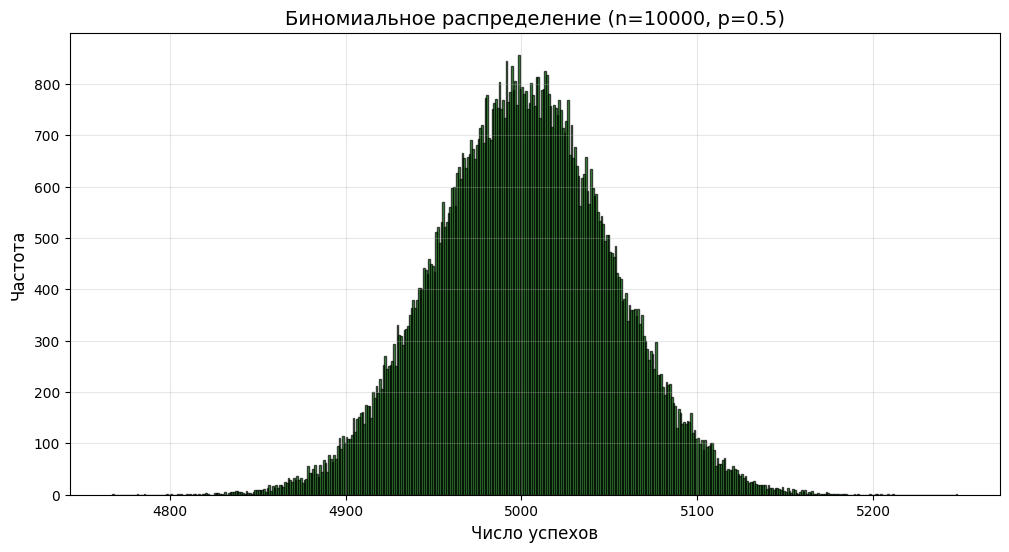

In [8]:
n = 10000
p = 0.5
sample_size = 100000
get_binomial(n,p, sample_size)

## Генератор геометрического распределения
Геометрическое распределение описывает число неудачных испытаний до первого успеха при независимых повторениях с постоянной вероятностью успеха.$\newline$
Функция вероятности геометрического распределения имеет вид $\mathbb{P}(X = n) = p(1 - p)^n. \newline$
Получим геометрическое распределение через экспоненциальное. Пусть $\xi \sim exp(\lambda)$, тогда $\lfloor \xi \rfloor \sim Geom(p)$, где $p = 1 - e^{-\lambda}$.
Покажем, что это так. Функция распределения имеет вид $F_\xi(x) = 1-e^{-\lambda x}$. Поэтому для $n \in \mathbb{N}_0$
$$
    \mathbb{P}(\lfloor \xi \rfloor = n) = \mathbb{P}(n \le \xi \le n + 1) = F_\xi(n+1) - F_\xi(n) =  e^{-n\lambda} (1 - e^{-\lambda}) = (1 - p)^np
$$
Таким образом, моделирование геометрического распределения с параметром p сводится к моделированию экспоненциального распределения с параметром $\lambda = - \ln(1 - p)$.
Воспользуемся методом обращения функции распределения:
$$
    F_\xi^{-1}(y) = -\frac{1}{\lambda}\ln(1 - y)
$$
Пусть случайная величина $\xi$ имеет непрерывную и строго возрастающую функцию распределения $F_\xi$. Тогда $F_\xi^{-1}(U) \sim \xi,\ U \sim \mathcal{U}(0, 1)$
$$
    \mathbb{P}(F_\xi^{-1}(U) < x) = \mathbb{P}(U < F_\xi(x)) = F_\xi(x),
$$
поэтому $F_\xi^{-1}(U) \sim \xi$

In [9]:
def get_geometric(p, n):#d-нез экспериментов
    if isinstance(n, (int, np.integer)):
        n = (n,)
    if p < 0 or p > 1:
        print("Некорректные параметры")
        return
    l = -np.log(1-p)#parameter
    return np.floor(-(1/l)*np.log(1 - np.random.rand(*n))).astype(int)#датчик экспон распр
#Геометрическое распределение — это распределение целого числа попыток до первого успеха.
#без floor геометрическое распределение не будет возвращать номер попытки


Теперь проверим, что для геометрического распределения выполняется свойство отсутствия памяти, т.е.: $$\mathbb{P}(X > m + n \mid X \geqslant n) = \mathbb{P}(X > m), \: X \sim Geom(p)$$


Мы имеем: $$\mathbb{P}(X > m) = (1 - p)^{m + 1}$$

Поэтому мы получим: $$\mathbb{P}(X > m + n \mid X \geqslant n) = \frac{\mathbb{P}(X > m + n, X \geqslant n)}{\mathbb{P}(X \geqslant n)} = \frac{(1 - p)^{m + n + 1}}{(1 - p)^n} = \mathbb{P}(X > m)$$
Что и требовалось доказать.

In [10]:
def check_memoryless_property(p, n, k):
    # Генерация выборки
    geom_sample = get_geometric(p, n)
    geom_sample_k = geom_sample[geom_sample > k] - k

    # Построение гистограмм
    bins = np.arange(1, max(geom_sample.max(), geom_sample_k.max()) + 1.5) - 0.5#не очень понимаю зачем это нужно
    #нужно понять зачем нужны разные параметры, и в особенности зачем bins

    plt.figure(figsize=(12, 6))
    plt.hist(geom_sample, bins=bins, alpha=0.5, color="green",label="Оригинальная выборка",density=True)
    plt.hist(geom_sample_k, bins=bins, alpha=0.5, color="red",label=f"Условная выборка (X > {k})", density=True)

    plt.xlabel("Значение")
    plt.ylabel("Относительная частота")
    plt.title("Свойство отсутствия памяти геометрического распределения")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, np.percentile(geom_sample, 99.9))
    plt.savefig('1_2_1.eps', format='eps')
    plt.show()


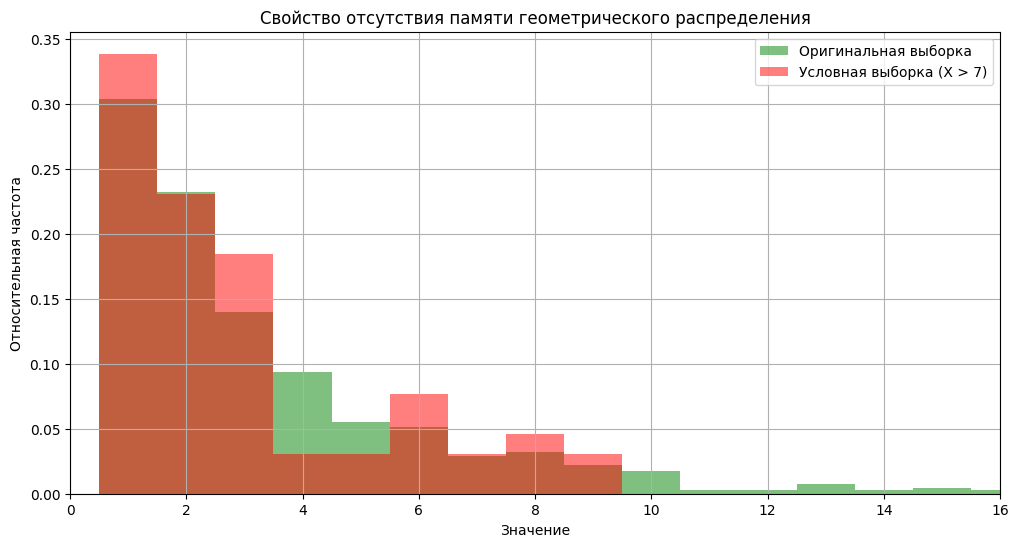

In [11]:
p = 0.3
n = 1000
check_memoryless_property(p, n, 7)

Игра в орлянку - бесконечная последовательность независимых испытаний с бросанием правильной монеты. Выйгрыш $S_n$ определяется как сумма по n испытаниям значений 1 и -1 в значении от выпавшей стороны. Проиллюстрируем поведение величины $Y(i) = \frac{S_i}{\sqrt n}$ как функцию номера испытания $i = 1, \dots ,n$ для отдельно взятой траектории.

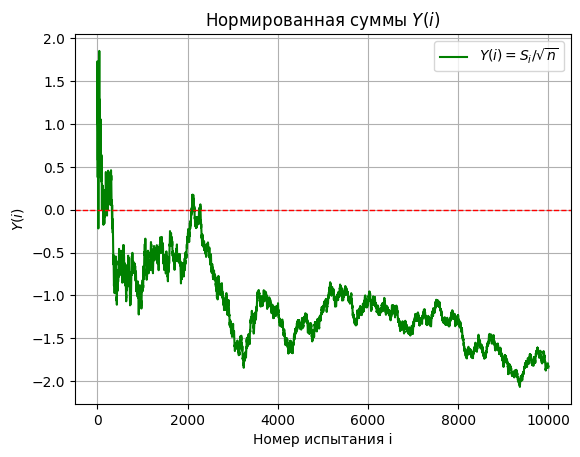

In [12]:
p = 0.5
n = 10000
game_res = [1 if bernoulli(p,1) == 1 else -1 for _ in range(n)]
s = [game_res[0]]
#сумма выигрышей
for i in range(n):
    if i != 0:
        s.append(s[i-1]+game_res[i])#сумма Y(i)

# нормированная сумма Y(i)
Y = s / np.sqrt(np.arange(1, n + 1))

#plt.plot(range(n),s)
plt.plot(Y, color="green",label='$Y(i) = S_i / \\sqrt{n}$')
plt.xlabel('Номер испытания i')
plt.ylabel('$Y(i)$')
plt.title('Нормированная суммы $Y(i)$')
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.legend()
plt.grid()
plt.show()
#ну или можно просто print(cumsum(game_res))

## Задание 2


Построим датчик сингулярного распределения с функцией распределения, совпадающей с канторовой лестницей.

Из определения канторовой лестницы следует, что каждая цифра в троичной записи значения случайной величины принимает значения $0$ или $2$ с вероятностью $\frac{1}{2}$.

Введём последовательность независимых одинаково распределённых случайных величин
$$
\xi_i \in \{0, 2\}, \qquad \mathbb{P}(\xi_i = 0) = \mathbb{P}(\xi_i = 2) = \frac{1}{2}.
$$

Тогда случайную величину с канторовым распределением можно представить в виде
$$
X = \sum_{i=1}^{\infty} \frac{\xi_i}{3^i}.
$$

В численных экспериментах будем использовать конечную сумму
$$
X_{20} = \sum_{i=1}^{20} \frac{\xi_i}{3^i},
$$
что обеспечивает достаточную точность аппроксимации канторова распределения.


In [13]:
def get_cantor(d):
    if isinstance(d, (int, np.integer)):
        d = (d,)
    N = 20
    X = 0.0
    for i in range(1, N + 1):
        xi = 2 * bernoulli(0.5, d)
        X += xi / (3 ** i)
    return X

In [14]:
#[get_cantor() for _ in range(20)]
k = get_cantor(10)
k

array([0.89012471, 0.22592597, 0.74379288, 0.91495067, 0.02868809,
       0.25515678, 0.32204182, 0.67499936, 0.76679827, 0.07544535])

Смоделируем функцию Кантора:


$$
C(x) =  \sum_{i=1}^{\infty} \frac{\xi_i}{2^i}.
$$



In [15]:
def cantor_function(x, max_iter=20):
    value = 0.0
    scale = 1.0

    for _ in range(max_iter):
        scale /= 2
        if x < 1/3:
            x *= 3
        elif x > 2/3:
            value += scale
            x = 3*x - 2
        else:
            value += scale
            break

    return value


In [16]:
cantor_function(k[0])

0.7626218795776367

Критерий Колмогорова:

Установим уровень значимости $\alpha$ = 0.05
1. Вычисляется максимальное отклонение:
$$
    D = \sup_x \lvert С_{emp}(x) - С(x) \rvert, где~С_{emp}(x)~и~С(x) - эмпирическая~и~истинная~функции~распределения.
$$
2. Используется статистика $ F_k $ для вычисления $ p $-value:
$$
    F_k = \sqrt(n) D = 1 + 2 \sum_{k=1}^\infty (-1)^{k} e^{-2k^2 D^2},    
$$
то есть:
$$
    F_k = 1 - 2 \sum_{k=1}^\infty (-1)^{k-1} e^{-2k^2 D^2},    
    p = 1 - F_k.
$$

Решение:
1. Если $ p > \alpha $, гипотеза принимается (расхождения несущественны).
2. Если $ p \leq \alpha $, гипотеза отвергается (расхождения значимы).


In [17]:
def empirical_df(sample, x):
    sample_sorted = np.sort(sample)
    n = len(sample_sorted)
    return np.searchsorted(sample_sorted, x, side='right') / n

In [18]:
def kolmogorov_df(x, max_iter=20):
    F = 1
    for i in range(1, max_iter + 1):
        F += 2 * (-1)**i*np.exp(-2*i**2 * x**2)
    return F

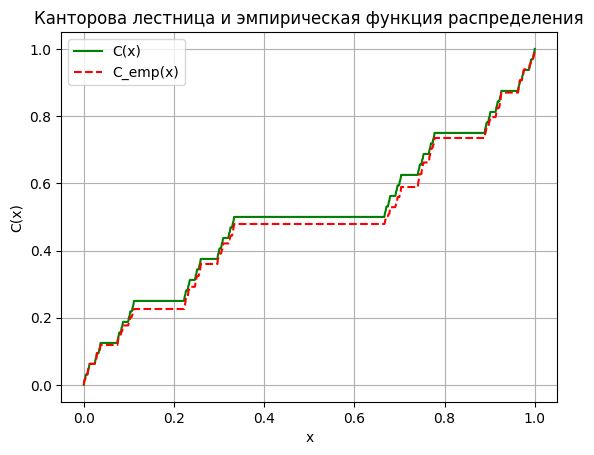

In [19]:
N = 1000
X = np.linspace(0, 1, N)
Y = np.zeros((N, 1))
Y_emp = np.zeros((N, 1))
sample = get_cantor(N)
for i in range(N):
    Y[i] = cantor_function(X[i])
    Y_emp[i] = empirical_df(sample, X[i])
plt.plot(X, Y, color="green",label = "C(x)")
plt.plot(X,Y_emp,'--',color="red", label = "C_emp(x)")
plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("C(x)")
plt.title("Канторова лестница и эмпирическая функция распределения")
plt.show()

In [20]:
#тут тест колмогорова
alpha = 0.1
N = 1000
M = 300          # число повторов эксперимента
rejected = 0
D = 0
for _ in range(M):
    x = np.sort(get_cantor(N))
    F0 = np.array([cantor_function(t) for t in x])

    Fn_left  = np.arange(0, N) / N
    Fn_right = np.arange(1, N + 1) / N
    D = np.max(np.maximum(np.abs(F0 - Fn_left), np.abs(F0 - Fn_right)))

    p_value = 1 - kolmogorov_df(np.sqrt(N) * D)

    if p_value < alpha:
        rejected += 1

print(f"Отвергли H0 {rejected} раз из {M} (ожидаемо около {alpha*M:.0f})")



Отвергли H0 29 раз из 300 (ожидаемо около 30)


Критерий Колмогорова подтвердил нулевую гипотезу.

## Проверка свойств канторова распределения критерием Смирнова

Напоминание: двухвыборочный критерий Смирнова (KS-test) сравнивает две выборки и измеряет
$$D_{n,m}=\sup_x\lvert \hat F_{1,n}(x)-\hat F_{2,m}(x)\rvert.$$
Если распределения одинаковы, то при больших $n,m$ статистика $\sqrt{\frac{nm}{n+m}}D_{n,m}$ имеет колмогоровское распределение.

Нам нужно проверить два свойства:
1) **Симметрия относительно $1/2$**: $X\overset{d}=1-X$.
2) **Самоподобие относительно деления на 3**: условное распределение $X\mid\{X\in[0,1/3]\}$ совпадает с распределением $X/3$.

In [21]:
alpha = 0.1

def empirical_cdf(sample, t):
    """
    Эмпирическая функция распределения:
    F_n(t) = доля элементов sample, не превосходящих t
    """
    return np.sum(sample <= t) / len(sample)

def ks_two_sample_statistic(x, y):
    """
    Двухвыборочная KS-статистика:
    D_{n,m} = sup_t |F_x(t) - F_y(t)|
    перебираем все точки из объединения выборок.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Все точки, где может быть скачок
    all_points = np.concatenate([x, y])

    D = 0.0
    for t in all_points:
        Fx = empirical_cdf(x, t)
        Fy = empirical_cdf(y, t)
        D = max(D, abs(Fx - Fy))

    return D

def ks_two_sample_pvalue(D, n, m):
    """
    Асимптотический p-value для двухвыборочного KS-теста
    """
    K = np.sqrt(n * m / (n + m)) * D
    return 1 - kolmogorov_df(K)

def sample_cantor_conditional(N, upper=1/3):
    """
    Выборка размера N из условного распределения X | X <= upper
    """
    result = []

    while len(result) < N:
        x = get_cantor(1000)      # генерируем много
        x = x[x <= upper]         # оставляем только X <= upper
        result.extend(x.tolist())

    return np.array(result[:N])#оставляем первые N значений

### 1. Симметрия относительно $1/2$: сравниваем $X$ и $1-X$

Симметрия «относительно $1/2$» означает, что отражение точки $x$ относительно $1/2$ даёт $1-x$.
Поэтому достаточно проверить однородность распределений выборок из $X$ и из $1-X$.


In [22]:
N = 1000
M = 300  # число повторов эксперимента
rejected = 0

for _ in range(M):
    x = get_cantor(N)
    y = 1 - get_cantor(N)  # независимая выборка 1 - X
    D = ks_two_sample_statistic(x, y)
    p = ks_two_sample_pvalue(D, N, N)
    if p < alpha:
        rejected += 1

print(f"Симметрия: отвергли H0 {rejected} раз из {M} (ожидаемо около {alpha*M:.0f})")

Симметрия: отвергли H0 29 раз из 300 (ожидаемо около 30)


### 2. Самоподобие при делении на 3: сравниваем $X\mid\{X\le 1/3\}$ и $X/3$

Строим две выборки одинакового размера:
- `x_cond`: из условного распределения $X\mid\{X\le 1/3\}$ (через отбраковку).
- `x_scaled`: из распределения $X/3$ (берём независимую выборку $X$ и делим на 3).

Дальше — тот же двухвыборочный KS-тест.

In [23]:
N = 1000
M = 300
rejected = 0

for _ in range(M):
    x_cond = sample_cantor_conditional(N, upper=1/3)
    x_scaled = get_cantor(N) / 3
    D = ks_two_sample_statistic(x_cond, x_scaled)
    p = ks_two_sample_pvalue(D, N, N)
    if p < alpha:
        rejected += 1

print(f"Самоподобие: отвергли H0 {rejected} раз из {M} (ожидаемо около {alpha*M:.0f})")

Самоподобие: отвергли H0 29 раз из 300 (ожидаемо около 30)


## Математическое ожидание и Дисперсия

Вычислим математическое ожидание случайной величины X.

Рассмотрим случайную величину $\xi_i \sim 2*\text{Bernoulli}(0.5)$, поэтому $\mathbb{E}[\xi_i] = 1$. Математическое ожидание $\mathbb{E}[X]$ выражается как:

$$
\mathbb{E}[X] = \sum_{i=1}^{\infty} \mathbb{E}[\xi_i] \cdot 3^{-i}.
$$

Сумма прогрессии:

$$
\sum_{i=1}^{\infty} 3^{-i} = \frac{1}{3-1} = \frac{1}{2}.
$$

Таким образом:

$$
\mathbb{E}[X] = 1 \cdot \frac{1}{2} = \frac{1}{2}.
$$
Аналогично, дисперсия $\text{Var}(X) = \frac{1}{8}$.



In [24]:
N = 100000
sample = get_cantor(N)
E_empirical = sum(sample) / N
D_empirical = sum((sample - E_empirical) ** 2) / N
print("Выборочное матожидание:", E_empirical)
print("Выборочная дисперсия:", D_empirical)

Выборочное матожидание: 0.49915175325936356
Выборочная дисперсия: 0.12486878543236685


Видим, что эмпирические значения близки к теоретическим.

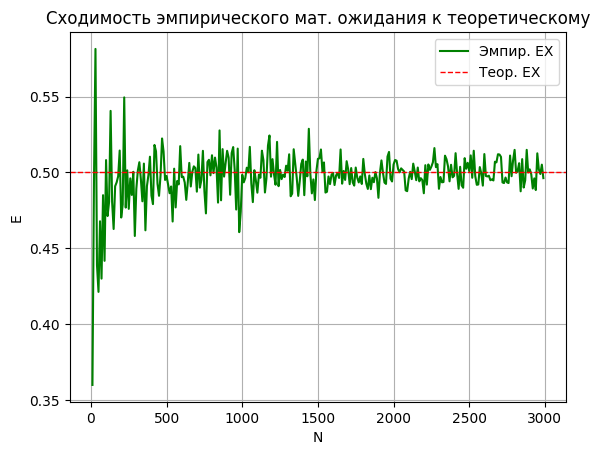

In [25]:
dot_quantity = 300 # Число точек на графике
E_emps = []
D_emps = []
Ns = []
for i in range(1,dot_quantity):
    N = i * 10
    sample = get_cantor(N)
    E_emps.append(sum(sample) / N)
    Ns.append(N)

plt.plot(Ns,E_emps,color="green",label = "Эмпир. EX")
plt.xlabel('N')
plt.ylabel('E')
plt.title('Сходимость эмпирического мат. ожидания к теоретическому')
plt.axhline(y=1/2, color='r', linestyle='--', linewidth=1, label = "Теор. EX")
plt.legend()
plt.grid()
plt.show()

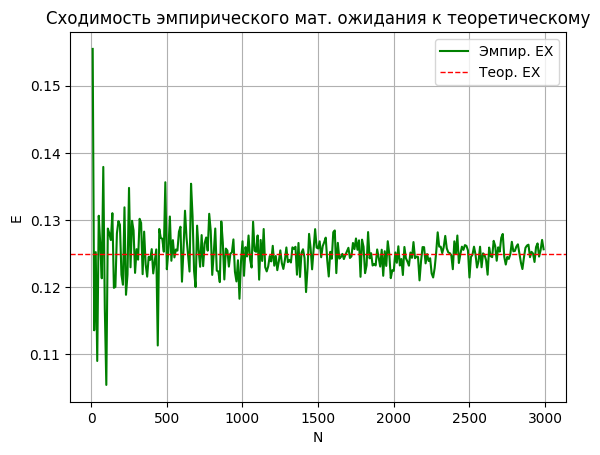

In [26]:
dot_quantity = 300 # Число точек на графике
E_emps = []
D_emps = []
Ns = []
for i in range(1,dot_quantity):
    N = i * 10
    sample = get_cantor(N)
    D_emps.append(sum((sample - E_empirical) ** 2) / N)
    Ns.append(N)

plt.plot(Ns,D_emps,color="green",label = "Эмпир. EX")
plt.xlabel('N')
plt.ylabel('E')
plt.title('Сходимость эмпирического мат. ожидания к теоретическому')
plt.axhline(y=1/8, color='r', linestyle='--', linewidth=1, label = "Теор. EX")
plt.legend()
plt.grid()
plt.show()

Обе величины сходятся к теоретическому значению

# Задание 3

Датчик экспоненциального распределения был получен в задаче 1 путем обращения функции распределения.

In [27]:
def get_exponential(l, d):
    if isinstance(d, (int, np.integer)):
        d = (d,)
    if l < 0:
        print("Некорректные параметры")
        return;
    return -(1/l)*np.log(1 - np.random.rand(*d))

In [28]:
get_exponential(1.6,1)

array([0.35084521])

In [29]:
def plot_exp_distribution(lam, n):
    x = get_exponential(lam, n)
    bins = 60

    xmax = np.quantile(x, 0.99)  # режем хвост, чтобы картинка читалась. берем значение ниже которого 99% выборки
    grid = np.linspace(0, xmax, 400)
    pdf = lam * np.exp(-lam * grid)#теор плотность

    plt.figure(figsize=(10, 5))
    plt.hist(x, bins=bins, density=True, alpha=0.6, edgecolor="black",color="green", linewidth=0.5)
    plt.plot(grid, pdf, linewidth=2,color="red")
    plt.title(f"Экспоненциальное распределение (λ={lam})")
    plt.xlabel("x")
    plt.ylabel("density")
    plt.grid(True)
    plt.show()

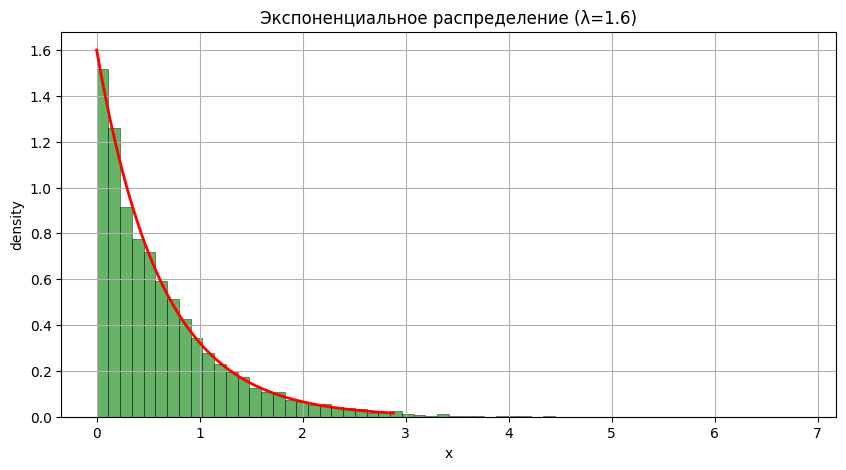

In [30]:
n = 10000
plot_exp_distribution(1.6,10000)


In [31]:
def memoryless_exp(lam, n, t):

    exp = get_exponential(lam, n)
    exp_t = exp[exp > t] - t

    exp_s = np.sort(exp)
    ecdf = np.arange(1, len(exp_s) + 1) / len(exp_s)

    exp_t_s = np.sort(exp_t)
    ecdf_sh = np.arange(1, len(exp_t_s) + 1) / len(exp_t_s)

    plt.figure(figsize=(10, 6))

    plt.step(exp_s, ecdf, color="green",label="Распределение $X$")
    plt.step(exp_t_s, ecdf_sh, linestyle="--",color="red", label=f"Распределение $X - t | X > t$")

    plt.xlabel("x")
    plt.ylabel("Функция распределения")
    plt.title("Проверка свойства отсутствия памяти")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [32]:
def memoryless_property_exp(p, n, k):
    # Генерация выборки
    exp_sample = get_exponential(p, n)
    exp_sample_k = exp_sample[exp_sample > k] - k

    # Построение гистограмм
    bins = np.arange(1, max(exp_sample.max(), exp_sample_k.max()) + 1.5) - 0.5#не очень понимаю зачем это нужно
    #нужно понять зачем нужны разные параметры, и в особенности зачем bins

    plt.figure(figsize=(12, 6))
    plt.hist(exp_sample, bins=bins, alpha=0.5, color="green",label="Оригинальная выборка",density=True)
    plt.hist(exp_sample_k, bins=bins, alpha=0.5,color="red", label=f"Условная выборка (X > {k})", density=True)

    plt.xlabel("Значение")
    plt.ylabel("Относительная частота")
    plt.title("Свойство отсутствия памяти геометрического распределения")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, np.percentile(exp_sample, 99.9))
    plt.savefig('1_2_1.eps', format='eps')
    plt.show()

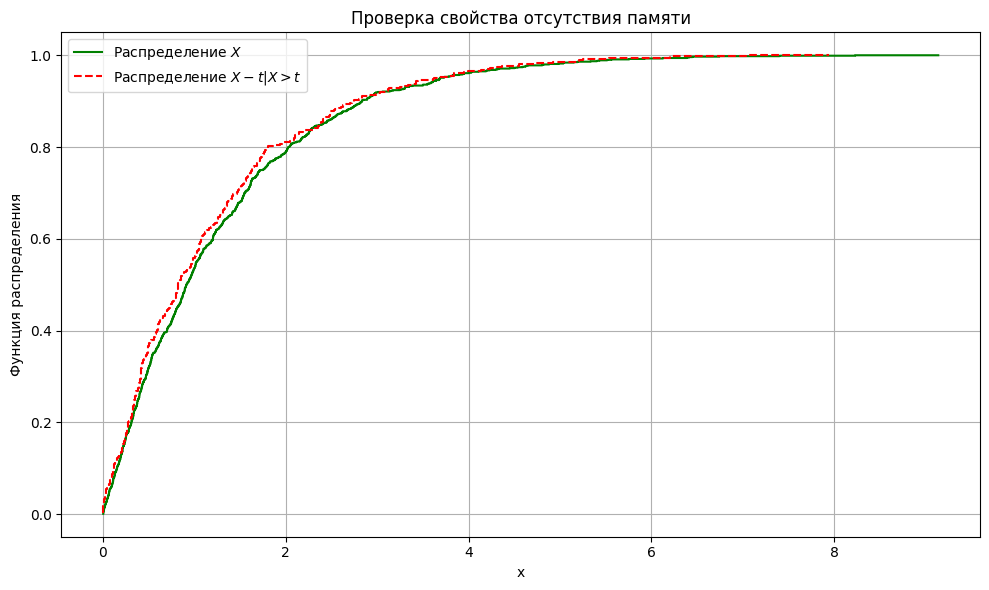

In [33]:
memoryless_exp(0.8, 1000, 1.2)

## Распределение с.в. Y
Пусть $X_1, \dots, X_n$ - независимые экспоненциально распределенные случайные величины с параметрами $(\lambda_1, \dots, \lambda_n)$. Найдем распределение случайной величины $Y = \min(X_1, \dots, X_n)$. Учитывая, что $\mathbb{P}(X > t) = e^{-\lambda t}$, получим:
$$\mathbb{P}(\min(X_1, \dots, X_n) > t) = \mathbb{P}(X_1 > t, \dots, X_n > t) = \prod_{k = 1}^n\mathbb{P}(X_k > t) = \prod_{k = 1}^n e^{-\lambda_k t} = e^{-(\lambda_1 + \ldots + \lambda_n) t}$$
Таким образом, полученная случайная величина имеет экспоненциальное распределение с параметром $\lambda = \lambda_1 + \ldots + \lambda_n$

In [34]:
def plot_min_exponentials(lambdas, n):

    lambdas = np.asarray(lambdas, dtype=float)

    if np.any(lambdas <= 0):
        raise ValueError("Все λ должны быть положительными")

    total_lambda = lambdas.sum()

    # --- моделирование Y ~ Exp(sum λ_i)
    u = np.random.rand(n)
    data = -np.log(u) / total_lambda

    #эмпирическая Ф-я распр-я
    sorted_data = np.sort(data)
    ecdf = np.arange(1, n + 1) / n

    #теоретическая
    xmax = np.quantile(sorted_data, 0.99)
    x = np.linspace(0, xmax, 1000)
    cdf = 1 - np.exp(-total_lambda * x)

    plt.figure(figsize=(10, 6))
    plt.step(sorted_data, ecdf, where="post",color="green",
             label="Эмпирическая CDF")
    plt.plot(x, cdf, linestyle="--",color="red",
             label=fr"Теоретическая CDF, $\lambda={total_lambda}$")

    plt.xlabel("x")
    plt.ylabel("F(x)")
    plt.title(r"Распределение $Y=\min(X_1,\dots,X_n)$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

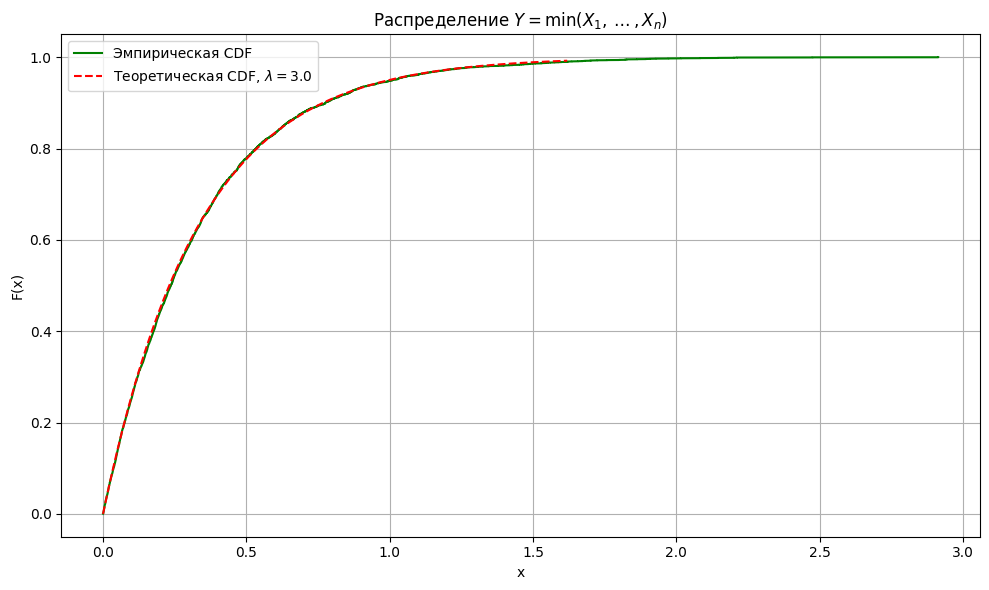

In [35]:
lambdas = [0.5, 1.0, 1.5]
n = 5000

plot_min_exponentials(lambdas, n)


## Датчик пуассоновского распределения.

В Пуассоновского процессе $N(t) \sim Pois(\lambda t)$ при фиксированном $t = 1$ получим:
$$
N(1)=\max\{n: T_1 +\dots + T_n\le 1\}, N(1) \sim Pois(\lambda), T_i \sim Exp(\lambda)
$$


In [36]:
def poisson_via_exp(l):
    t_max = 1
    n = 1
    if l <= 0.0:
        raise ValueError("lam must be > 0")
    T = np.sum(get_exponential(l,1))
    while T < t_max:
        T += np.sum(get_exponential(l,1))
        n+=1
    return n

In [37]:
def plot_poisson(lam, n):
    x = poisson_via_exp(1.6, 100)

    bins = 60

    xmax = np.quantile(x, 0.99)  # режем хвост, чтобы картинка читалась. берем значение ниже которого 99% выборки
    grid = np.linspace(0, xmax, 400)
    pdf = lam * np.exp(-lam * grid)#теор плотность

    plt.figure(figsize=(10, 5))
    plt.hist(x, bins=bins, density=True, alpha=0.6, edgecolor="black", linewidth=0.5)
    plt.plot(grid, pdf, linewidth=2)
    plt.title(f"Распределение Пуассона (λ={lam})")
    plt.xlabel("x")
    plt.ylabel("density")
    plt.grid(True)
    plt.show()

In [38]:
#надо сделать проверку plot_poisson, он сейчас не работает

## Датчик Пуассоновского распределения как предел Биномиального
Распределение биномиальной случайной величины:
$$
P(X = k) = C_n^k p^k (1 - p)^{n-k}, \quad k = 0, 1, 2, \dots, n,
$$

Биномиальное распределение при $ n \to \infty, \, p \to 0, \, n \cdot p = \lambda $:
$$
P(X = k) \approx \frac{\lambda^k e^{-\lambda}}{k!}, \quad \lambda = n \cdot p.
$$

In [39]:
def poisson_via_binom(l, d):#нужно просто бооооольшой n взять)
    if l < 0:
        print("Некорректные параметры")
        return;
    if isinstance(d, int):
        d = (d,)
    n = 1000
    return get_binom(l/n, n, d)

Проверим правильность при помощи критерия согласия Пирсона. В нем используется статистика хи-квадрат:
$$
\chi^2 = n \sum_{i = 0}^k \frac{(\frac{n_i}{n} - \mathbb{P}_i(X))^2}{\mathbb{P}_i(X)},
$$
где $n_i$ - число значений, равных $i$, $\mathbb{P}_i(X) = \mathbb{P}(X = i)$ при $i = \overline{0,k-1}$; $n_k$ - число значений, больших либо равных $k$, $\mathbb{P}_k(X) = \mathbb{P}(X \ge k)$.

Зафиксируем уровень значимости $\alpha = 0.05$. Нулевая гипотеза о том, что выборка порождена пуассоновским распределением принимается, если значение функции распределения $\chi^2_{k-1}$ на статистике $\chi_2$ больше уровня значимости, иначе она отвергается. k выбирается так, чтобы при каждом значении $i < k$ было достаточно элементов выборки, равных $i$ (>5).

In [40]:
k = 10
N = 1000
l = 2
M = 1000
alpha = 0.05

rejected = 0

for _ in range(M):
    sample = poisson_via_binom(l, N)

    # теоретические вероятности P(X=i), i=0..k-1
    p = np.exp(-l)   # p0
    p_sum = 0.0
    chi2 = 0.0

    for i in range(k):
        obs = np.count_nonzero(sample == i) / N
        chi2 += (obs - p)**2 / p
        p_sum += p
        p = p * l / (i + 1)  # следующий p

    # хвост: X >= k
    p_tail = 1.0 - p_sum
    obs_tail = np.count_nonzero(sample >= k) / N
    chi2 += (obs_tail - p_tail)**2 / p_tail

    chi2 *= N

    # степени свободы: категорий (k + 1) => df = (k + 1) - 1 = k
    df = k

    # классический p-value (правый хвост)
    p_value = 1 - st.chi2.cdf(chi2, df)

    # rejected = сколько раз H0 НЕ отвергли (тест "прошёл")
    if p_value < alpha:
        rejected += 1

print(f"Отвергли H0 {rejected} раз из {M} (ожидаемо около {alpha*M:.0f})")


Отвергли H0 87 раз из 1000 (ожидаемо около 50)


## Датчик стандартного нормального распределения

Воспользуемся методом Бокса-Мюллера. Генерация стандартного нормального распределения:
$$
Z_1 = \sqrt{-2 \ln U_1} \cos(2 \pi U_2), \quad Z_2 = \sqrt{-2 \ln U_1} \sin(2 \pi U_2),
$$
где $ U_1, U_2 \sim \text{Uniform}(0, 1) $.

In [41]:
def box_muller(size):
    if size <= 0:
        raise ValueError('size должно быть положительным')
    n = size if size % 2 == 0 else size + 1
    u1 = np.random.rand(n // 2)
    u2 = np.random.rand(n // 2)

    r = np.sqrt(-2 * np.log(u1))
    theta = 2 * np.pi * u2

    z1 = r * np.cos(theta)
    z2 = r * np.sin(theta)
    samples = np.concatenate([z1, z2])
    return samples[:size]

In [42]:
def plot_stand_norm(n):
    x = box_muller(n)
    bins = 60

    xmax = np.quantile(x, 0.99)  # режем хвост, чтобы картинка читалась. берем значение ниже которого 99% выборки
    grid = np.linspace(-xmax, xmax, 500)
    pdf = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * (grid)**2)#теор плотность

    plt.figure(figsize=(10, 5))
    plt.hist(x, bins=bins, density=True, alpha=0.6, color="green",edgecolor="black", linewidth=0.5)
    plt.plot(grid, pdf,color="red", linewidth=2)
    plt.title(f"Стандартное нормальное распределение")
    plt.xlabel("x")
    plt.ylabel("density")
    plt.grid(True)
    plt.show()

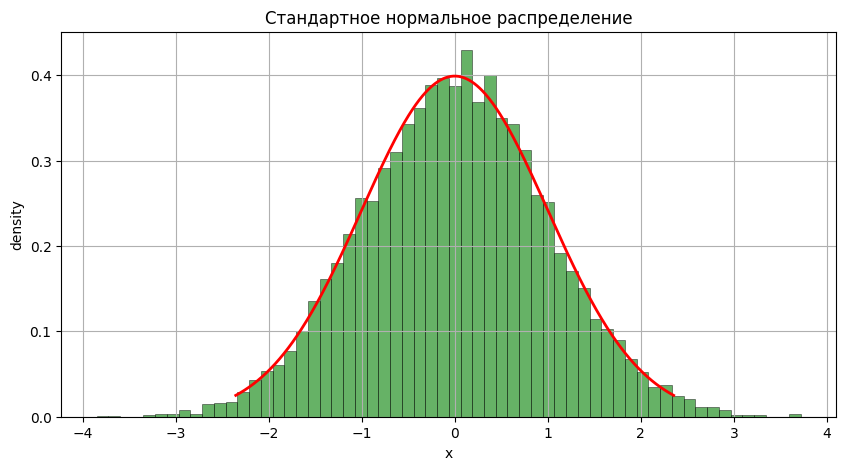

In [43]:
plot_stand_norm(10000)

## Критерий t-Стьюдента
Критерий t-Стьюдента используется для проверки гипотезы о равенстве мат. ожидания выборки заданному значению:
$$
H_0: \mu = \mu_0, \quad H_1: \mu \neq \mu_0.
$$
Статистика t-критерия
$$
t = \sqrt n \frac{\bar{X} - \mu_0}{S}
$$
где:
- $\bar{X} = \frac{1}{n} \sum_{i=1}^n X_i$ - выборочное среднее
- $S = \sqrt {\frac{1}{n-1} \sum_{i = 0}(X_i - \bar{X})}$ - стандартное несмещённое отклонение
- $n$ - объём выборки



In [44]:
N = 1000 #объём выборки
M = 1000
rejected = 0
alpha = 0.05
for j in range(M):
    sample = box_muller(N)
    E = sum(sample) / N
    s = np.sqrt(sum((sample - E)**2)/(N - 1))
    m = 0
    t = (E - m) / (s/np.sqrt(N))
    p_value = 2 * min(1 - st.t.cdf(t, N - 1), st.t.cdf(t, N - 1))
    if p_value < alpha:
        rejected += 1
print(f"Отвергли H0 {rejected} раз из {M} (ожидаемо около {alpha*M:.0f})")


Отвергли H0 56 раз из 1000 (ожидаемо около 50)


Нулевая гипотеза верна

# Критерий Фишера
Критерий Фишера используется для проверки гипотезы о равенстве
дисперсий двух выборок:
$$
H_0:S_1^2 = S_2^2, \quad H_1:S_1^2 \neq S_2^2
$$
Статистика:
$$
F = \frac{S_1^2}{S_2^2}
$$

In [45]:
N = 1000
M = 1000
rejected = 0
alpha = 0.05
for j in range(M):
    sample1 = box_muller(N)
    E1 = sum(sample1) / N
    s1 = sum((sample1 - E1)**2)/N
    sample2 = box_muller(N)
    E2 = sum(sample2) / N
    s2 = sum((sample2 - E2)**2)/N
    F = s1/s2
    p_value = 2 * min(1 - st.f.cdf(F, N - 1, N - 1), st.f.cdf(F, N - 1, N - 1))
    if p_value < alpha:
        rejected += 1
print(f"Отвергли H0 {rejected} раз из {M} (ожидаемо около {alpha*M:.0f})")

Отвергли H0 50 раз из 1000 (ожидаемо около 50)


Нулевая гипотеза верна.
# Задание 3

## Датчик распределения Коши

Функция Распределения случайной величины, имеющей распределение Коши $C(x_0, \gamma)$ с параметрами $x_0 \in \mathbb R$ и $\gamma > 0$ имеет следующую функцию распределения:
$$
    F_X(x) = \frac{1}{\pi}\arctan(\frac{x - x_0}{\gamma}) + \frac{1}{2}
$$
где:
- $x_0 \in \mathbb R$ - параметр сдвига
- $\gamma > 0$ - параметром масштаба

Воспользуемся методом обратной функции распределения.

Обратная функция распределения Коши имеет вид:
$$
F^{-1}(y) = x_0 + \gamma \tan\!\left( \pi \left( y - \frac{1}{2} \right) \right).
$$

Будем использовать её для моделирования распределения Коши:
$$
\xi = F^{-1}(U) \sim \mathcal{C}(x_0, \gamma),
\qquad U \sim Uniform(0,1).
$$


In [46]:
def get_cauchy(x0, gamma,d):
    if gamma <= 0:
        print("Некорректные параметры")
        return;
    if isinstance(d, (int, np.integer)): # Modified this line
        d = (d,)
    return x0 + gamma*np.tan(np.pi*(np.random.rand(*d) - 1/2))

In [47]:
def plot_cauchy(n, x0 = 0.0, gamma = 1.0):
    xlim = (-10,10)
    x = get_cauchy(x0, gamma, n)
    bins = 200#60
    xmax = np.linspace(xlim[0], xlim[1], 2000)
    #xmax = np.quantile(np.abs(x - x0), 0.99)  # режем хвост, чтобы картинка читалась. берем значение ниже которого 99% выборки
    grid = np.linspace(-xmax, xmax, 500)
    pdf = 1 / (np.pi * gamma * (1 + ((grid - x0)/gamma)**2))#теор плотность

    plt.figure(figsize=(10, 5))
    #plt.hist(x, bins=bins, density=True,range=(x0-xmax,x0+xmax), alpha=0.6, edgecolor="black", linewidth=0.5)
    plt.hist(x, bins=bins, density=True, range=xlim, alpha=0.6, edgecolor="black",color="green", linewidth=0.5, label="Эмпирическая")
    plt.plot(grid, pdf, linewidth=1, label="Теоретическая", color="red")
    plt.title("Распределение Коши")
    plt.xlabel("x")
    plt.ylabel("PDF")
    plt.grid(True)
    plt.show()

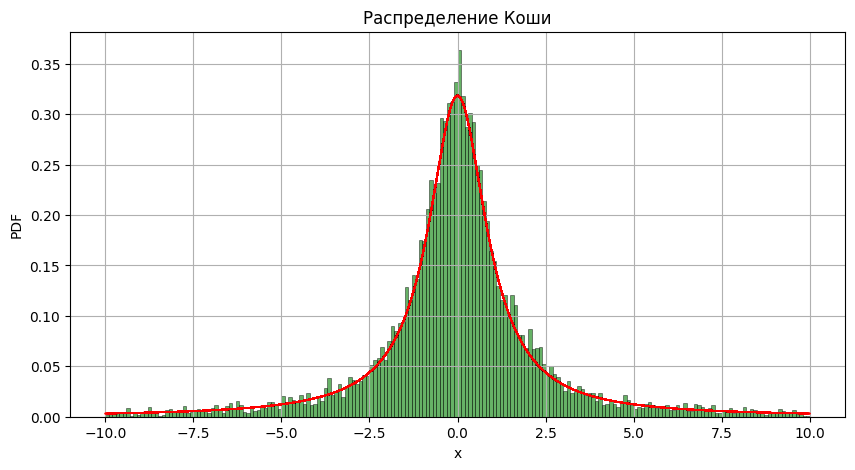

In [48]:
plot_cauchy(10000)

## Метод эллиминации Фон Неймана(Rejection Sampling)


Метод фон Неймана (accept–reject, rejection sampling) используется для моделирования случайных величин $X \sim \mathcal N(0,1)$ с заданной плотностью $f(x)$ в ситуации, когда прямое моделирование затруднено, но доступен датчик для другого распределения с плотностью $g(x)$.$\newline$
Идея метода состоит в следующем. Пусть требуется получить выборку из распределения с плотностью $f(x)$, а мы умеем генерировать случайные величины с плотностью $g(x)$. Предполагается, что существует такая константа $M > 0$, что
$$
f(x) \le M g(x), \quad \forall x \in \mathbb{R}.
$$
Для каждой случайной выборки с плотностью $f(x)$ мы генерируем значение случайной величины и принимаем его в случае, если оно удовлетворяет неравенству:
$$
U \leq \frac{f(Y)}{M g(Y)}
$$
где
- $ U \sim \text{Uniform}(0, 1) $
- $Y \sim \mathcal C(0,1)$.

Величину $Y$ моделируем методом обратной функции:
$$
Y=\tan\bigl(\pi(U-\tfrac12)\bigr), \quad U\sim Uniform(0,1).
$$
Теоретическое распределение Коши:
$$
f_C(x) = \frac{1}{\pi(1 + x^2)}
$$
Нормальное распределение:
$$
f_N(x) = \frac{e^\frac{-x^2}{2}}{\sqrt(2\pi)}
$$


In [49]:
def standard_cauchy_pdf(x):
    return 1 / np.pi / (x**2 + 1)
def standard_normal_pdf(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

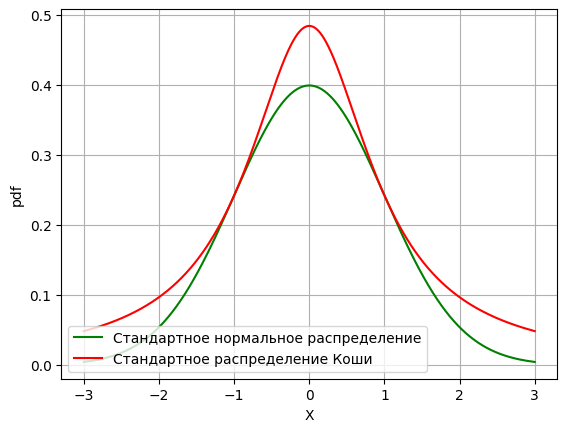

In [50]:
N = 1000
X = np.linspace(-3, 3, N)
plt.plot(X, standard_normal_pdf(X),color="green")
plt.plot(X, np.sqrt(2*np.pi/np.e)*standard_cauchy_pdf(X), color="red")
plt.xlabel("X")
plt.ylabel("pdf")
plt.legend(["Стандартное нормальное распределение", "Стандартное распределение Коши"], loc='lower left')
plt.grid(True)
plt.show()

Будем искать минимальную константу $M$, так как это влияет на скорость метода. Будем искать супремум отношения $r(x) = \frac{f(x)}{g(x)}$.
$$
r(x) = \frac{f(x)}{g(x)} = \sqrt\frac{\pi}{2}(x^2 + 1)e^{-\frac{x^2}{2}}
$$
$$
r'(x) = \sqrt\frac{\pi}{2}\left(xe^{\frac{-x^2}{2}} - (x^2 + 1)\frac{x^2}{2}xe^{-\frac{x^2}{2}}\right) = \sqrt\frac{\pi}{2}xe^{-\frac{x^2}{2}}\frac{1}{2}\left(2 - x^4 - x^2\right) = 0 \Rightarrow x = 0,\, x = \pm 1.
$$
$$
r(0) = \sqrt\frac{\pi}{2},\, \quad r(\pm 1) = \sqrt\frac{2\pi}{e}.
$$
Так как $M = sup_x r(x)$, то из:
$$
 \sqrt\frac{2\pi}{e} > \sqrt\frac{\pi}{2} \Rightarrow M = \sqrt\frac{2\pi}{e}.
 $$

 Смысл метода в том, что мы генерируем значение из известного распределения $x$ и принимаем его в выборку целевого распределения с вероятностью $\frac{f(x)}{Mg(x)}$. Обоснуем применимость метода. Рассмотрим плотность вероятности при условии, что мы приняли значение:
$$
    p(x|A) = \frac{\mathbb{P}(A|x)p(x)}{\mathbb{P}(A)} = \frac{\frac{f(x)}{Mg(x)}g(x)}{\mathbb{P}(A)}
$$
$$
    \mathbb P(A) = \int_{-\infty}^{+\infty} \frac{f(x)}{Mg(x)} g(x) \mathrm dx = \int_{-\infty}^{+\infty} \frac{f(x)}{M} \mathrm dx = \frac{1}{M}
$$
$$
    p(x|A) = \frac{\frac{f(x)}{Mg(x)}g(x)}{\frac{1}{M}} = f(x)
$$
Таким образом, мы получаем нужную плотность распределения.

In [51]:
def get_standard_normal_rs(d):
  M = np.sqrt(2*np.pi/np.e)#конст
  if isinstance(d, (int, np.integer)):
      d = (d,)
  N = np.prod(d)#произв-е размерностей
  F = []#в списке удобнее, потом просто отсеим до N
  while len(F) < N:
    candidates = get_cauchy(0,1,N)#кандидаты из распр-я Коши
    P = standard_normal_pdf(candidates)/(M*standard_cauchy_pdf(candidates))
    P = np.minimum(P, 1.0)
    F.extend(candidates[np.random.rand(*d) < P])
  return np.array(F)[0:N].reshape(d)

In [52]:
def plot_standard_normal_rs(d):
    xlim = (-5,5)
    x = get_standard_normal_rs(d)
    bins = 200#60
    #xmax = np.linspace(xlim[0], xlim[1], 2000)
    #xmax = np.quantile(np.abs(x - x0), 0.99)  # режем хвост, чтобы картинка читалась. берем значение ниже которого 99% выборки
    grid = np.linspace(xlim[0], xlim[1], 500)
    pdf = np.exp(-grid**2/2) / np.sqrt(2*np.pi)#теор плотность
    plt.figure(figsize=(10, 5))
    plt.hist(x, bins=bins, density=True, range=xlim, alpha=0.6, edgecolor="black",color="green", linewidth=0.5, label="Эмпирическая")
    plt.plot(grid, pdf, linewidth=1, label="Теоретическая", color="red")
    plt.title("Стандартное нормальное распределение(RS)")
    plt.xlabel("x")
    plt.ylabel("PDF")
    plt.grid(True)
    plt.show()


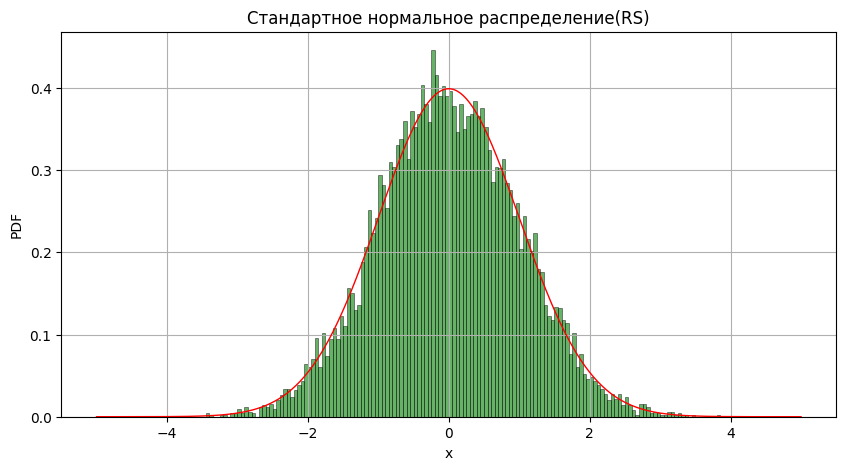

In [53]:
plot_standard_normal_rs(10000)

Проверим с помощью метода Normal Probability Plot(Q-Q plot) соответствует ли форма распределения всей выборки нормальному закону.

Normal Probability Plot это график, на котором отображаются квантили выборки (по оси $y$) против квантилей теоретического нормального распределения (по оси $x$). Если выборка распределена нормально, точки на графике будут лежать на прямой линии.$\newline$
Любое нестандартное нормальное распределение можно представить в виде $\mu + \sigma \mathcal N(0, 1)$, то есть в виде линейного преобразования стандартного, поэтому график также будет линейным. Для других распределений квантили ведут себя по другому, поэтому график не будет линейным. Также графики не будут инвариантны относительно параметров масштаба и сдвига.

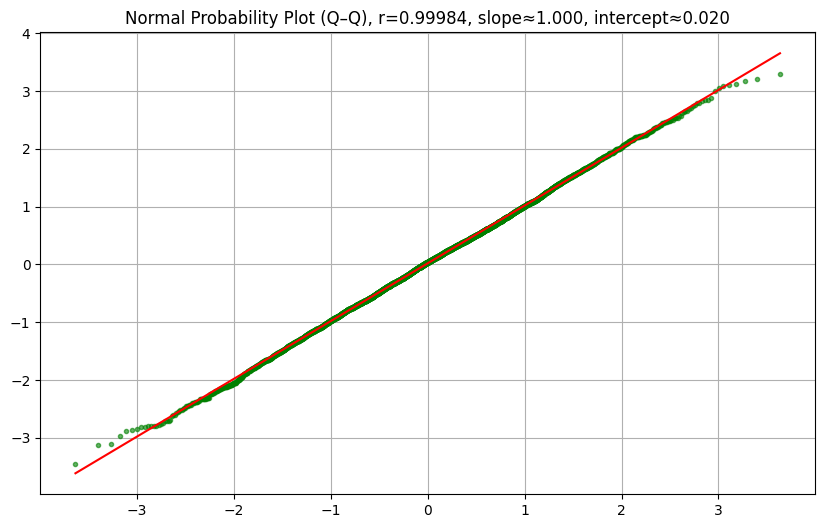

In [54]:
size = 5000
sample_normal = np.asarray(get_standard_normal_rs(size)).ravel() #лучше перевести в одномерный массив
# Q–Q plot + параметры линии
(osm, osr), (slope, intercept, r) = st.probplot(sample_normal, dist="norm")

plt.figure(figsize=(10, 6))
plt.plot(osm, osr, 'o', markersize=3,color="green", alpha=0.6)
plt.plot(osm, slope*osm + intercept, '-',color="red", linewidth=1.5)
plt.title(f'Normal Probability Plot (Q–Q), r={r:.5f}, slope≈{slope:.3f}, intercept≈{intercept:.3f}')
plt.grid(True)
plt.show()


# Сравнение скоростей работы

метод Бокса-Мюллера, n=100: 0.000024 sec
метод Фон Неймана, n=100: 0.000184 sec
метод Бокса-Мюллера, n=500: 0.000031 sec
метод Фон Неймана, n=500: 0.000197 sec
метод Бокса-Мюллера, n=1000: 0.000050 sec
метод Фон Неймана, n=1000: 0.000337 sec
метод Бокса-Мюллера, n=5000: 0.000321 sec
метод Фон Неймана, n=5000: 0.001377 sec
метод Бокса-Мюллера, n=10000: 0.000388 sec
метод Фон Неймана, n=10000: 0.002676 sec
метод Бокса-Мюллера, n=50000: 0.001938 sec
метод Фон Неймана, n=50000: 0.013951 sec


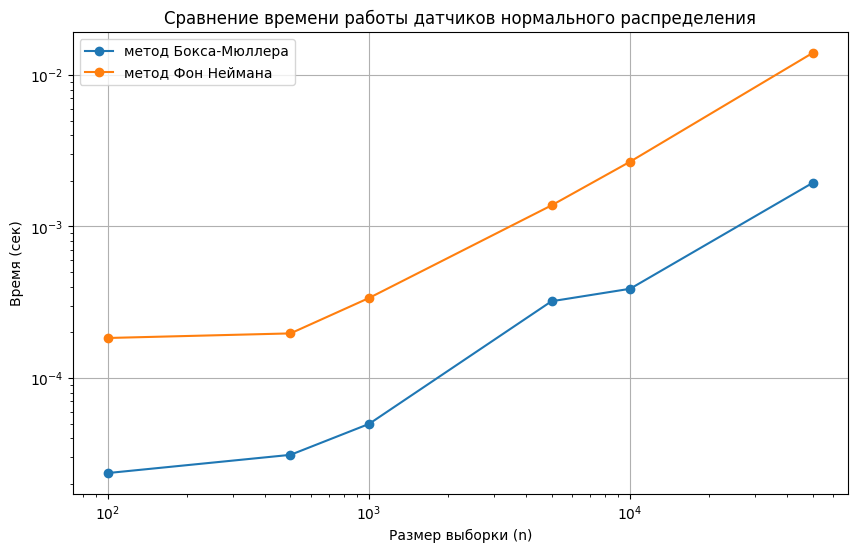

In [55]:
def measure_time(func, n, repeats=100):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        func(n)
        end = time.perf_counter()
        times.append(end - start)
    return np.median(times)

# Параметры
sizes = [100, 500, 1000, 5000, 10000, 50000]
methods = {
    "метод Бокса-Мюллера": box_muller,
    "метод Фон Неймана": get_standard_normal_rs,
}

# Измерение
results = {name: [] for name in methods}
for n in sizes:
    for name, func in methods.items():
        t = measure_time(func, n, repeats=100)
        results[name].append(t)
        print(f"{name}, n={n}: {t:.6f} sec")

# Построение графика
plt.figure(figsize=(10, 6))
for name, times in results.items():
    plt.plot(sizes, times, marker='o', label=name)

plt.xlabel("Размер выборки (n)")
plt.ylabel("Время (сек)")
plt.title("Сравнение времени работы датчиков нормального распределения")
plt.legend()
plt.grid(True)
plt.xscale("log")
plt.yscale("log")
plt.show()

По графику видно, что метод Бокс-Мюллера работает значительно быстрее.

# Задание 5

## ЗБЧ и ЦПТ
Убедиться эмприрически в справедливости закона больших чисел (ЗБЧ) и центральной предельной теоремы(ЦПТ): исследовать поведение суммы $S_n = \sum_{i=1}^n X_i$ и эмпирического распределения величины:
$$
\sqrt{n} ( \frac{S_n}{n} - a).
$$
Рассмотрим независимые одинакого распределенные случайные величины: $X_i \sim \mathcal{N} (\mu, \sigma^2)$. Убедимся эмприрически в справедливости закона больших чисел (ЗБЧ). Рассмотрим выборочное среднее $\bar{X}_n = \frac{X_1 + \dots + X_n}{n}$, и покажем что $\bar{X}_n \xrightarrow[n \to \infty]{p} \mu$.

In [56]:
from scipy.special import erf
from scipy.stats import t, chi2

In [57]:
def get_normal(mu, sigma, d):
    return mu + sigma * box_muller(d)

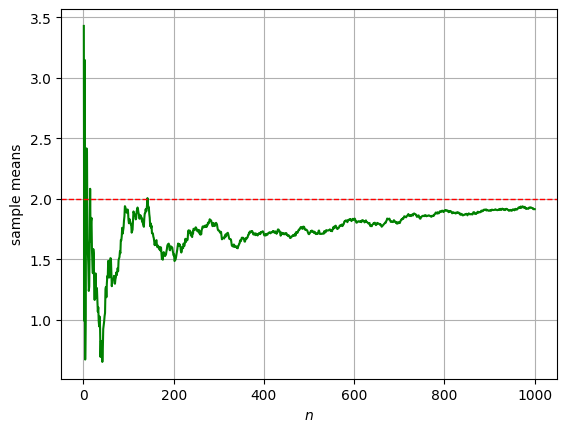

In [58]:
#ЗБЧ
N = 1000
mu = 2
sigma = 4
sample = get_normal(mu, sigma, N)
S = np.cumsum(sample)
X = np.arange(1, N+1)
sample_means = S / X

plt.plot(X, sample_means,color="green")
plt.axhline(y=mu, color='red', linestyle='--', linewidth=1)
plt.xlabel("$n$")
plt.ylabel("sample means")
plt.grid()
plt.show()

ЦПТ же гласит, что $Y = \frac{S_n - \mu n}{\sigma \sqrt n} \xrightarrow[n \to \infty]{d} \mathcal{N}(0, 1)$, где $S_n = X_1 + \dots + X_n$. Сходимость по распределению означает, что распределение получившейся величины близко к целевому.

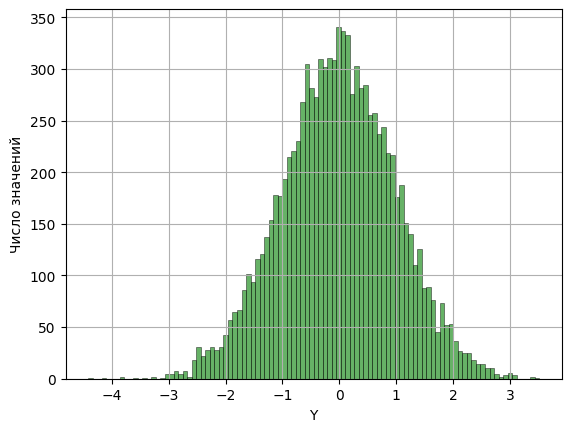

In [59]:
n = 100 # Число слагаемых в сумме
N = 10000 # Число моделирований суммы
mu = 1
sigma = 2

sample = []
for i in range(N):
    S = sum(get_normal(mu, sigma, n))
    sample.append((S - mu*n) / (sigma * np.sqrt(n)))
n_bins = 100
plt.hist(sample, bins = n_bins,alpha=0.6, edgecolor="black",color="green", linewidth=0.5)
plt.xlabel("Y")
plt.ylabel("Число значений")
plt.grid()
plt.show()

По графику видно, что распределение соответствует нормальному.

## Построение доверительных интервалов

Пусть $X_1,\dots,X_n$ — независимые случайные величины, $X_i \sim \mathcal N(\mu,\sigma^2)$, где параметры $\mu$ и $\sigma$ неизвестны.

Обозначим выборочные оценки:
$$
\bar X = \frac{1}{n}\sum_{i=1}^n X_i,\qquad
S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2.
$$

## Доверительный интервал для $\mu$ (уровень доверия $1-\alpha$)

Для нормальной выборки при неизвестной $\sigma$ верно:
$$
T=\frac{\bar X-\mu}{S/\sqrt{n}} \sim t_{n-1}.
$$
Отсюда доверительный интервал:
$$
\mu \in \left[\bar X - t_{1-\alpha/2,n-1}\frac{S}{\sqrt{n}},\;
\bar X + t_{1-\alpha/2,n-1}\frac{S}{\sqrt{n}}\right].
$$
где:
- $t_{n-1, 1-\frac{\alpha}{2}}$ — квантиль распределения Стьюдента с $n-1$ степенями свободы;
- $n$ — размер выборки;
- $\alpha$ — уровень значимости.

## Доверительный интервал для $\sigma^2$ (уровень доверия $1-\alpha$)

Для нормальной выборки:
$$
\frac{(n-1)S^2}{\sigma^2} \sim \chi^2_{n-1}.
$$
Отсюда доверительный интервал:
$$
\sigma^2 \in
\left[
\frac{(n-1)S^2}{\chi^2_{1-\alpha/2,n-1}},\;
\frac{(n-1)S^2}{\chi^2_{\alpha/2,n-1}}
\right].
$$
где:
- $(n-1)S^2 = \sum_{i=1}^n (X_i - \overline{X})^2$ — несмещённая оценка дисперсии;
- $\chi^2_{n-1, p}$ — квантиль распределения $\chi^2$ с $n-1$ степенями свободы.


In [60]:
n_samples = 50000
alpha = 0.05
mu = 3
sigma = 2

sample = get_normal(mu, sigma, n_samples)
#cтатистики
x_bar = np.mean(sample)
s = np.std(sample, ddof=1)#ddof=1 => деление на n-1
s2 = s**2

df = n - 1  # степени свободы

#Доверительный интервал для мат. ож.
t_q = st.t.ppf(1 - alpha/2, df=df)   # квантиль t-распр.
half_mu = t_q * s / np.sqrt(n)          # "половина" интервала (margin)

ci_mu = (x_bar - half_mu, x_bar + half_mu)

print(f"Доверительный интервал для мат. ожидания: ({ci_mu[0]:.4f}, {ci_mu[1]:.4f})")

#Доверительный интервал для дисперсии
chi2_low = st.chi2.ppf(alpha/2, df=df)
chi2_high = st.chi2.ppf(1 - alpha/2, df=df)

ci_sigma2 = (df * s2 / chi2_high, df * s2 / chi2_low)

print(f"Доверительный интервал для дисперсии: ({ci_sigma2[0]:.4f}, {ci_sigma2[1]:.4f})")

Доверительный интервал для мат. ожидания: (2.6152, 3.4062)
Доверительный интервал для дисперсии: (3.0631, 5.3622)


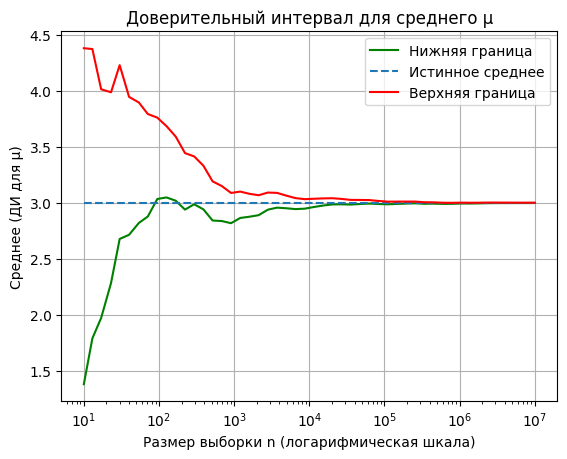

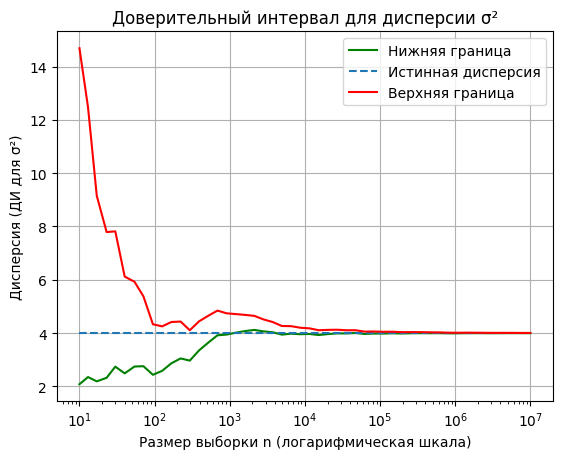

In [61]:

alpha = 0.05
mu = 3
sigma = 2

# 1) Сетка размеров n (как у тебя)
sample_sizes = np.unique(np.logspace(1, 7, 50).astype(int))
N_max = sample_sizes[-1]

X = get_normal(mu,sigma,N_max)

#здесь будем хранить пары(нижняя, верхняя) границ
mean_intervals = []
var_intervals = []

for n in sample_sizes:
    x_n = X[:n]                    # один и тот же "поток" данных, просто больше первых элементов
    df = n - 1

    x_bar = x_n.mean()             # \bar X
    s = x_n.std(ddof=1)            # S
    s2 = s**2                      # S^2 (чтобы не считать var отдельно)

    #Доверительный интервал для mu
    t_q = st.t.ppf(1 - alpha/2, df=df)
    half_mu = t_q * s / np.sqrt(n)               # это и есть margin / half-width
    mean_intervals.append((x_bar - half_mu, x_bar + half_mu))

    #Доверительный интервал для sigma^2
    chi2_low = st.chi2.ppf(alpha/2, df=df)
    chi2_high = st.chi2.ppf(1 - alpha/2, df=df)
    ci_sigma2 = (df * s2 / chi2_high, df * s2 / chi2_low)
    var_intervals.append(ci_sigma2)

# нижняя и верхняя границы как функции от n(для графика)
mean_left = [a for a, b in mean_intervals]
mean_right = [b for a, b in mean_intervals]

var_left = [a for a, b in var_intervals]
var_right = [b for a, b in var_intervals]

#график для mu
plt.figure()
plt.plot(sample_sizes, mean_left, color="green",label='Нижняя граница')
plt.plot(sample_sizes, [mu] * len(sample_sizes), label='Истинное среднее', linestyle='--')
plt.plot(sample_sizes, mean_right,color="red",label='Верхняя граница')
plt.xscale('log')
plt.xlabel('Размер выборки n (логарифмическая шкала)')
plt.ylabel('Среднее (ДИ для μ)')
plt.title('Доверительный интервал для среднего μ')
plt.grid(True)
plt.legend()
plt.show()

#график для sigma^2
plt.figure()
plt.plot(sample_sizes, var_left, color="green",label='Нижняя граница')
plt.plot(sample_sizes, [sigma**2] * len(sample_sizes), label='Истинная дисперсия', linestyle='--')
plt.plot(sample_sizes, var_right, color="red",label='Верхняя граница')
plt.xscale('log')
plt.xlabel('Размер выборки n (логарифмическая шкала)')
plt.ylabel('Дисперсия (ДИ для σ²)')
plt.title('Доверительный интервал для дисперсии σ²')
plt.grid(True)
plt.legend()
plt.show()


### Поведение нормированных сумм для распределения Коши

Пусть $X_i \sim C(a,b)$ — независимые одинаково распределённые случайные величины
(распределение Коши со сдвигом $a$ и масштабом $b$), а $S_n=\sum_{i=1}^n X_i$.

У распределения Коши характеристическая функция имеет вид
$$
\varphi(t)=\mathbb{E}e^{itX}=e^{ita-b|t|}.
$$

Тогда для нормированной суммы $\frac{S_n}{n}$:
$$
\varphi_{S_n/n}(t)=\mathbb{E}e^{itS_n/n}
= \left(\varphi\!\left(\frac{t}{n}\right)\right)^n
= \left(e^{i(t/n)a-b|t|/n}\right)^n
= e^{ita-b|t|}
= \varphi(t).
$$

Следовательно,
$$
\frac{S_n}{n} \sim C(a,b)\quad \forall n.
$$

Из-за тяжёлых хвостов распределения Коши отдельные наблюдения могут давать большой вклад в сумму,
поэтому сходимость $\frac{S_n}{n}$ к константе отсутствует (в частности, математическое ожидание не существует).


In [62]:
#пользуемся написанным раннее датчиком Коши
def plot_running_mean_cauchy(a=1.0, b=2.0, n_max=2000):

    x = get_cauchy(a, b, n_max)      # X_1,...,X_n
    s = np.cumsum(x)
    n = np.arange(1, n_max + 1)
    y = s / n

    plt.figure()
    plt.plot(n, y, color="green")
    plt.xscale("log")
    plt.axhline(a, linestyle="--",color="red")
    plt.xlabel("n")
    plt.ylabel(r"$S_n/n$")
    plt.title(rf"Одна траектория $S_n/n$ для $C(a={a}, b={b})$ (сходимости нет)")
    plt.show()



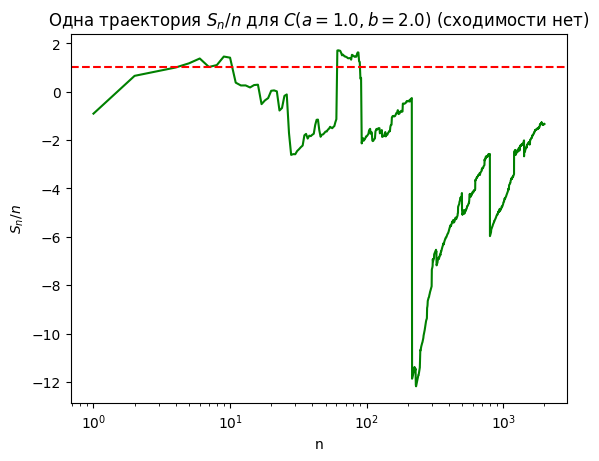

In [63]:
plot_running_mean_cauchy(a=1.0, b=2.0, n_max=2000)

На графике одной реализации видно, что величина $𝑆_𝑛/𝑛$ при увеличении
n не стабилизируется и может резко изменяться. Такие скачки связаны с появлением отдельных больших значений, характерных для распределения Коши. Это наглядно показывает, что в данном случае среднее не сходится при росте числа слагаемых.

# Задание 6
Требуется вычислить следующий интеграл:
$$
    I = \int_{-\infty}^{+\infty} \int_{-\infty}^{+\infty} \dots \int_{-\infty}^{+\infty} \frac{e^{-\left(x_1^2 + \dots + x_{10}^2 + \frac{1}{2^7\cdot x_1^2 \cdot \dots \cdot x_{10}^2}\right)}}{x_1^2 \cdot \dots \cdot x_{10}^2} \mathrm{d}x_1 \mathrm{d} x_2 \dots \mathrm{d} x_{10}
$$

### Метод Монте–Карло для вычисления интеграла

Метод Монте–Карло основан на моделировании случайных величин и использовании выборочных средних для приближённого вычисления интересующих величин. В задачах численного интегрирования этот метод применяется следующим образом.

Пусть требуется вычислить интеграл
$$
\int_a^b f(x)\,\mathrm dx.
$$
Рассмотрим случайную величину $U$, равномерно распределённую на отрезке $[a,b]$. Тогда величина $f(U)$ также является случайной, и её математическое ожидание равно
$$
\mathbb E f(U)=\int_a^b f(x)\varphi(x)\,\mathrm dx,
$$
где $\varphi(x)=\frac{1}{b-a}$ — плотность распределения $U$.
Отсюда следует представление
$$
\int_a^b f(x)\,\mathrm dx=(b-a)\,\mathbb E f(U).
$$
Таким образом, значение интеграла можно приближённо найти, вычисляя выборочное среднее значений $f(U)$, полученных при моделировании равномерной случайной величины.Любой интеграл можно переписать как матожидание подходящей случайной величины.

Аналогичную идею применим к рассматриваемому многомерному интегралу. Пусть имеются случайные величины
$$
X_i\sim\mathcal{N(\mu=0,\sigma^2=\frac{1}{2})}\quad i=\overline{1,10},
$$
Тогда плотность каждой компоненты имеет вид
$$
p_i(x_i)=\frac{1}{\sqrt{\pi}}e^{-x_i^2},
$$
а совместная плотность вектора
$$
X=(X_1,\dots,X_{10})
$$
равна
$$
p(x)=\prod_{i=1}^{10}p_i(x_i)
=\frac{1}{\pi^5}\exp\!\left(-(x_1^2+\dots+x_{10}^2)\right),
\quad x\in\mathbb R^{10}.
$$

Введём обозначения
$$
y=\frac{1}{x_1^2\cdots x_{10}^2},
\qquad
f(x)=\pi^5\,y\,\exp\!\left(-\frac{y}{2^7}\right).
$$
Тогда исходный интеграл может быть представлен в виде математического ожидания:
$$
I=\int_{\mathbb R^{10}} f(x)\,p(x)\,\mathrm dx=\mathbb E f(X).
$$

Следовательно, для приближённого вычисления интеграла достаточно смоделировать $n$ независимых реализаций вектора $X$, вычислить соответствующие значения $f(X_k)$ и использовать выборочное среднее
$$
\overline X_n=\frac{1}{n}\sum_{k=1}^n f(X_k)
$$
в качестве оценки математического ожидания $\mathbb E f(X)$.

Для оценки погрешности воспользуемся неравенством Чебышёва:
$$
\mathbb P\bigl(|\overline X_n-\mathbb E X|\ge\varepsilon\bigr)
\le
\frac{\mathbb D X}{n\varepsilon^2}.
$$
Дисперсия $\mathbb D X$ аппроксимируется несмещённой выборочной дисперсией
$$
s_n^2=\frac{1}{n-1}\sum_{k=1}^n\bigl(f(X_k)-\overline X_n\bigr)^2.
$$
При достаточно большом размере выборки $(n\ge100)$ эта оценка обладает хорошей точностью. В результате получаем
$$
\mathbb P\bigl(|\overline X_n-\mathbb E X|\ge\varepsilon\bigr)
\le
\frac{s_n^2}{n\varepsilon^2}
=1-\alpha.
$$

В дальнейших вычислениях фиксируем $\varepsilon=1$ и $n=10^7$.


In [64]:
def f(x):#p(x = (X1,...,X10)
    y = 1 / np.prod(x, 0) ** 2
    return np.pi ** 5 * y * np.exp(-y / 2**7)

In [65]:
N = 10000000
eps = 1.0
n_runs = 10

reliability = [] #надёжности(1-alpha)
S = [] #оценки интеграла
results = [] #пары

for i in range(n_runs):
    X = st.norm.rvs(loc=0, scale=1/np.sqrt(2), size=(10, N))  # 10 x N
    sample = f(X)   # N зн-й

    I_hat = np.mean(sample) # оценка I = E[f(X)]
    s2 = np.var(sample, ddof=1) # несмещённая дисперсия

    alpha_hat = s2 / (N * eps**2) # оценка верхней границы по Чебышёву

    # p должно быть на [0,1]
    #single_reliability = float(np.clip(reliability, 0.0, 1.0))

    reliability.append(1-alpha_hat)
    S.append(I_hat)
    results.append([reliability[-1], S[-1]])

In [66]:
df = pd.DataFrame({"1 - Альфа": reliability, "Значение интеграла": S})
df

,1 - Альфа,Значение интеграла
0,0.870107,124.944481
1,0.869946,125.021508
2,0.869970,125.004500
3,0.870282,124.759874
4,0.870023,124.907279
5,0.869537,125.245970
6,0.870287,124.875187
7,0.870088,124.819422
8,0.870454,124.597405
9,0.870221,124.715777


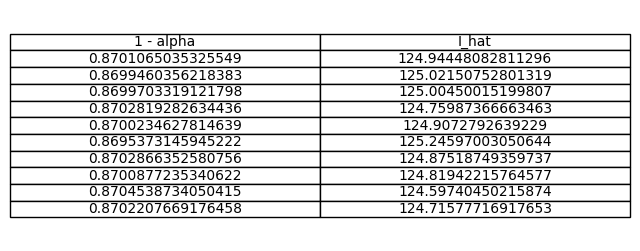

In [67]:
fig, ax = plt.subplots(figsize=(8, 3))# no visible frame
ax.xaxis.set_visible(False)  # hide the x axis
ax.yaxis.set_visible(False)  # hide the y axis
ax.axis('off')
headers = ['1 - alpha', 'I_hat']
table = ax.table(cellText=results,
                colLabels=headers,
                cellLoc='center',
                loc='center')

(1 - alpha) - вероятность вычисленного значения попасть в доверительный интервал $[I - \varepsilon, I + \varepsilon],\, \varepsilon = 1$.

### Метод Квадратур

### Численное вычисление интеграла методом квадратур

Для приближённого вычисления интеграла воспользуемся квадратурным методом, основанным на замене переменных и последующем применении метода прямоугольников.

Рассмотрим замену переменных
$$
x_i = \tan y_i,\qquad
\mathrm dx_i = \frac{\mathrm dy_i}{\cos^2 y_i},
\quad i=\overline{1,10}.
$$
При такой замене область интегрирования $\mathbb R^{10}$ переходит в гиперкуб
$[-\tfrac{\pi}{2},\,\tfrac{\pi}{2}]^{10}$.

После подстановки интеграл принимает вид
$$
\int_{-\frac{\pi}{2}}^{\frac{\pi}{2}}\!\!\dots
\int_{-\frac{\pi}{2}}^{\frac{\pi}{2}}
\exp\!\left(
-\sum_{i=1}^{10}\tan^2 y_i
-2^{-7}\prod_{i=1}^{10}\cot^2 y_i
\right)
\prod_{i=1}^{10}\frac{1}{\sin^2 y_i}\,
\mathrm dy_1\dots \mathrm dy_{10}.
$$

Обозначим
$$
y=(y_1,\dots,y_{10}),
$$
$$
f(y)=
\exp\!\left(
-\sum_{i=1}^{10}\tan^2 y_i
-2^{-7}\prod_{i=1}^{10}\cot^2 y_i
\right)
\prod_{i=1}^{10}\frac{1}{\sin^2 y_i}.
$$
Тогда интеграл можно записать в компактной форме:
$$
I=\int_{[-\frac{\pi}{2},\,\frac{\pi}{2}]^{10}} f(y)\,\mathrm dy.
$$

Поскольку подынтегральная функция является чётной по каждой переменной, область интегрирования может быть ограничена положительным ортантам:
$$
I = 2^{10}\int_{[0,\,\frac{\pi}{2}]^{10}} f(y)\,\mathrm dy.
$$

Для численного вычисления данного интеграла применим **метод средних прямоугольников**. Разобьём отрезок $[0,\tfrac{\pi}{2}]$ на $N$ равных частей длины
$$
h=\frac{\pi}{2N}.
$$
В качестве узлов квадратурной формулы используем середины отрезков:
$$
T=\left\{\frac{h}{2},\,\frac{3h}{2},\,\dots,\,\frac{(2N-1)h}{2}\right\}
=\{T_0,\dots,T_{N-1}\}.
$$

Переходя к декартовому произведению $T^{10}$, получаем равномерную 10-мерную сетку. Итоговая квадратурная формула имеет вид
$$
I \approx 2^{10}\,h^{10}\sum_{y\in T^{10}} f(y).
$$


In [68]:
def f_y(y):
    t = np.tan(y)
    s = np.sin(y)

    tan2_sum = np.sum(t * t, axis=-1)# sum_i tan^2(y_i)
    cot2_prod = np.prod(1.0 / (t * t), axis=-1) # prod_i cot^2(y_i) = prod 1/tan^2
    csc2_prod = np.prod(1.0 / (s * s), axis=-1) # prod_i csc^2(y_i) = prod 1/sin^2

    return np.exp(-tan2_sum - (2.0 ** -7) * cot2_prod) * csc2_prod

In [69]:
d = 10  #10-мерный интеграл
N = 5   #число разбиений на [0, pi/2]
a, b = 0.0, np.pi / 2
h = (b - a) / N # шаг сетки

# узлы метода средних прямоугольников: середины отрезков
T = a + (np.arange(N) + 0.5) * h

# строение 10-мерной сетки T^10
grids = np.meshgrid(*([T] * d), indexing="ij") # d массивов формы (N,...,N)
Y = np.stack(grids, axis=-1).reshape(-1, d) # точки сетки в виде массива (N^d, d)

# квадратурная формула: I ≈ 2^d * h^d * sum_{y in T^d} f(y)
I = (2.0 ** d) * (h ** d) * np.sum(f_y(Y))
print("I_quadrature =", I)


I_quadrature = 116.39025860063632


Можно существенно сократить вычисления, заметив, что функция не меняет значение при перестановке аргументов. Тогда интеграл можно записать как
$$
    I = \sum_{0 \le k_1 \le k_2 \le \dots \le k_{10} \le N-1} \frac{N!}{n_1!\cdot \dots \cdot n_{N}!} f(T_{k_1}, \dots, T_{k_{10}}),
$$
где $n_i$ - число индексов, равных $i - 1, \quad i = \overline{1, N}$.

In [70]:
def multinomial(lst):
    res, i = 1, sum(lst)
    i0 = lst.index(max(lst))
    for a in lst[:i0] + lst[i0+1:]:
        for j in range(1,a+1):
            res *= i
            res //= j
            i -= 1
    return res

def integrate_numerically(N):
    n = 10
    a = 0
    b = np.pi/2
    h = (b - a) / N
    T = np.linspace(h/2, b - h/2, N)
    ind = itertools.combinations_with_replacement(range(N), n)
    I = 0
    for i in ind:
        i = list(i)
        count = list(collections.Counter(i).values())
        count = count[:N] + [0]*(N - len(count))
        I += f(T[i])*multinomial(count)
    return 2**10*I*h**10

In [71]:
print(integrate_numerically(6))
print(integrate_numerically(12))

177977299.806724
167740980.70236945


При значении $N = 5$ полученный результат совпадает с предыдущими вычислениями. Однако использование симметрии подынтегральной функции позволяет рассматривать более плотные разбиения и тем самым повышать точность численного интегрирования.

Рассмотрим оценку погрешности метода средних прямоугольников. Для этого разложим функцию
$f(\mathbf{x})$ в ряд Тейлора в окрестности центра $\mathbf{c}$ элементарного гиперкуба:
$$
f(\mathbf{x}) \approx
f(\mathbf{c})
+ \sum_{k=1}^n \frac{\partial f}{\partial x_k}\Big|_{\mathbf{c}}(x_k-c_k)
+ \frac{1}{2}\sum_{k,l=1}^n
\frac{\partial^2 f}{\partial x_k\partial x_l}\Big|_{\mathbf{c}}
(x_k-c_k)(x_l-c_l) + \dots
$$

В силу симметрии области интегрирования вклад линейных (нечётных) членов в интеграл равен нулю. Основной вклад в погрешность даёт квадратичная часть разложения. Интегрирование этих членов по одному гиперкубу приводит к оценке
$$
\text{погрешность на одном гиперкубе}
\;\sim\;
\frac{h^2}{24}
\sum_{k=1}^n
\frac{\partial^2 f}{\partial x_k^2}\Big|_{\mathbf{c}}
\cdot h^n.
$$

Пусть все вторые производные функции ограничены константой $M$. Тогда суммарная погрешность по всей области интегрирования оценивается сверху как
$$
E \sim
N^n \cdot \frac{h^2}{24} \cdot M \cdot h^n
= \frac{M}{24}\,(b-a)^n\,h^2.
$$

Несмотря на квадратичную зависимость от шага $h$, в многомерном случае возникает принципиальная проблема: число узлов сетки
$$
N^n = \left(\frac{b-a}{h}\right)^n
$$
растёт экспоненциально с увеличением размерности $n$. Это означает, что для достижения высокой точности требуется существенно уменьшать шаг разбиения, что приводит к резкому росту числа вычислений.

Таким образом, применение классических квадратурных методов в пространствах высокой размерности оказывается вычислительно неэффективным. Данное явление известно как *проклятие размерности*.


# Задание 7

## 7.1. Минимизация функции $f$ методом случайного поиска

Требуется найти минимальное значение функции
$$
f(x_1, x_2) = x_1^3 \sin\frac{1}{x_1} + 10 x_1 x_2^4 \cos\frac{1}{x_2},
\quad x_1 \neq 0,\; x_2 \neq 0,
$$
на множестве
$$
A = \{(x_1, x_2) \in \mathbb{R}^2 \mid x_1^2 + x_2^2 \le 1\}.
$$

При $x_1 = 0$ или $x_2 = 0$ функция доопределяется по непрерывности.

### Анализ доопределения по непрерывности

Рассмотрим поведение слагаемых функции при стремлении аргументов к нулю.

Для первого слагаемого:
$$
|x_1^3 \sin(1/x_1)| \le |x_1|^3 \xrightarrow[x_1 \to 0]{} 0.
$$

Для второго слагаемого:
$$
|x_2^4 \cos(1/x_2)| \le |x_2|^4 \xrightarrow[x_2 \to 0]{} 0.
$$

Следовательно, корректное доопределение функции в точках $x_1=0$ и $x_2=0$ заключается в приравнивании соответствующих слагаемых к нулю.



In [72]:
def f(x1, x2):
    if x1 == 0 or x2 == 0:
        return 0.0
    return x1**3 * np.sin(1 / x1) + 10 * x1 * x2**4 * np.cos(1 / x2)

## Метод случайного поиска
Идея метода случайного поиска следующая: на каждом шаге из текущей точки делается случайная попытка перейти в новую точку на фиксированном расстоянии $r$.

Если новая точка:
1. остаётся внутри допустимой области;
2. даёт меньшее значение функции,

то переход принимается. Иначе остаёмся в текущей точке.

В качестве критерия остановки будем использовать заранее заданное число итераций.

In [73]:
def random_search(func, step, radius, n_steps):
    x, y = 0.0, 0.0

    for _ in range(n_steps):
        angle = 2 * np.pi * np.random.rand()
        cand_x1 = x + step * np.cos(angle)
        cand_x2 = y + step * np.sin(angle)

        inside_circle = cand_x1**2 + cand_x2**2 <= radius**2
        if inside_circle and func(cand_x1, cand_x2) < func(x, y):
            x, y = cand_x1, cand_x2

    return x, y


In [74]:
def plot_rs_res(step, radius, n_steps, n_runs=5):
    rows = []

    for run in range(1, n_runs + 1):
        x, y = random_search(f, step, radius, n_steps)
        value = f(x, y)
        rows.append([run, f"{x:.8f}", f"{y:.8f}", f"{value:.8f}"])
        print(f"run {run}: x = {x:.8f}, y = {y:.8f}, f(x, y) = {value:.8f}")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=["№", "x1", "x2", "f(x1, x2)"],
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)
    plt.show()

run 1: x = 0.31912987, y = -0.51385431, f(x, y) = -0.08129089
run 2: x = 0.27319421, y = -0.49952477, f(x, y) = -0.08119018
run 3: x = 0.24629569, y = -0.10368944, f(x, y) = -0.01215173
run 4: x = -0.25272919, y = -0.16314359, f(x, y) = -0.01351879
run 5: x = -0.23049674, y = 0.20585579, f(x, y) = -0.01199942


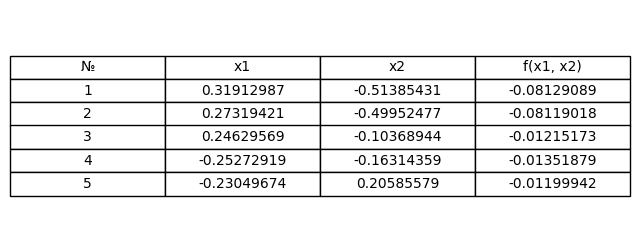

In [75]:
r = 0.1
R = 1
n_iter = 100000

plot_rs_res(r, R, n_iter)

run 1: x = -0.04262613, y = 0.03332551, f(x, y) = -0.00007713
run 2: x = -0.04268110, y = 0.01061149, f(x, y) = -0.00007708
run 3: x = 0.04269261, y = -0.01649825, f(x, y) = -0.00007709
run 4: x = -0.04268008, y = 0.02348646, f(x, y) = -0.00007709
run 5: x = -0.04266544, y = -0.00661516, f(x, y) = -0.00007707


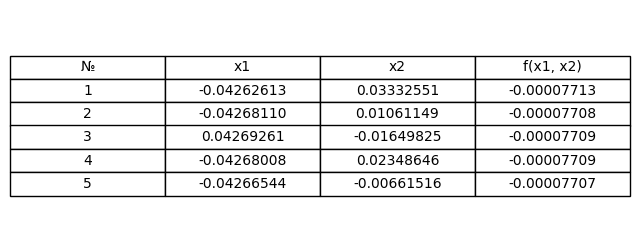

In [76]:
r = 0.01
R = 1
n_iter = 100000

plot_rs_res(r, R, n_iter)

run 1: x = 0.01355271, y = -0.00518383, f(x, y) = -0.00000249
run 2: x = 0.01355318, y = 0.00394563, f(x, y) = -0.00000249
run 3: x = -0.01481471, y = 0.00378137, f(x, y) = -0.00000325
run 4: x = -0.01355263, y = -0.00110195, f(x, y) = -0.00000249
run 5: x = -0.01355264, y = 0.00793513, f(x, y) = -0.00000249


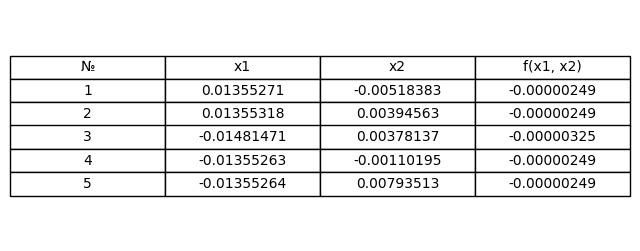

In [77]:
r = 0.001
R = 1
n_iter = 100000

plot_rs_res(r, R, n_iter)

По результатам видно, что выбор шага заметно влияет на поведение алгоритма. При слишком маленьком шаге метод становится стабильнее, но чаще «застревает» в одном из локальных минимумов. При более крупном шаге он исследует область активнее, однако итоговые значения сильнее колеблются от запуска к запуску.

### Результаты метода случайного поиска

В результате работы алгоритма получено приближённое значение глобального минимума функции $f$ на диске.
Точность результата зависит от количества случайных точек и параметров локального уточнения.


Для наглядности сохраним траекторию одного запуска метода случайного поиска.

x = -0.01355250, y = -0.00151422, f(x, y) = -0.00000249


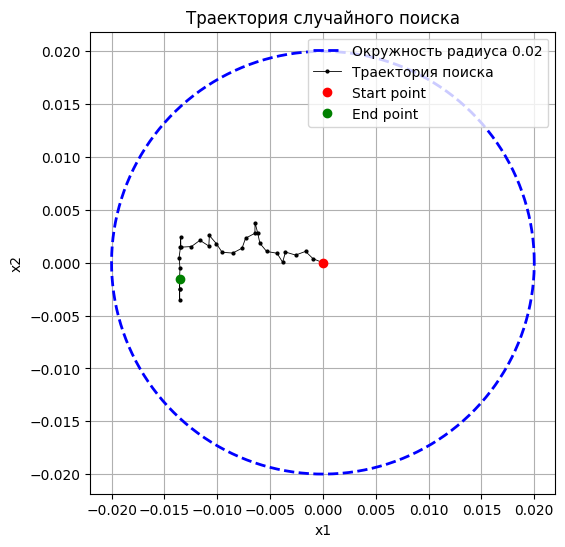

In [78]:
step = 0.001
radius = 1
n_steps = 100000

x, y = 0.0, 0.0
xs, ys = [x], [y]

for _ in range(n_steps):
    angle = 2 * np.pi * np.random.rand()
    cand_x = x + step * np.cos(angle)
    cand_y = y + step * np.sin(angle)

    if cand_x**2 + cand_y**2 <= radius**2 and f(cand_x, cand_y) < f(x, y):
        x, y = cand_x, cand_y
        xs.append(x)
        ys.append(y)

#грфик единичной окружности для наглядности
angles = np.linspace(0, 2 * np.pi, 500)
r_c = 0.02
# 2. Вычисляем координаты x и y по формулам: x = cos(t), y = sin(t)
x_c = r_c * np.cos(angles)
y_c = r_c * np.sin(angles)

print(f"x = {x:.8f}, y = {y:.8f}, f(x, y) = {f(x, y ):.8f}")
plt.figure(figsize=(6, 6))
plt.xlabel("x1")
plt.ylabel("x2")
plt.plot(x_c, y_c,"--", color='blue', linewidth=2, label='Окружность радиуса 0.02')
plt.plot(xs, ys, "ko-", markersize=2, linewidth=0.6,label="Траектория поиска")
x_start, y_start = xs[0], ys[0]
plt.plot(x_start, y_start, "ro", markersize=6, label="Start point")
x_end, y_end = xs[-1], ys[-1]
plt.plot(x_end, y_end, "go", markersize=6, label="End point")
plt.grid(True)
plt.axis("equal")
plt.title("Траектория случайного поиска")
plt.legend(loc='upper right')
plt.show()

## 7.2. Метод имитации отжига для функции Розенброка

Рассмотрим функцию Розенброка:
$$
g(x_1, x_2) = (x_1 - 1)^2 + 100(x_2 - x_1^2)^2.
$$

Глобальный минимум достигается в точке $(1,1)$, где $g(x)=0$.
 ### Основные идеи метода имитации отжига

Новый кандидат формируется по формуле
$$
x_{k+1} = x_k + \mathcal{N}(0, \sigma^2 T_k).
$$

Если
$$
\Delta g = g(x_{k+1}) - g(x_k) \le 0,
$$
кандидат принимается.  
Иначе переход осуществляется с вероятностью
$$
p = \exp\left(-\frac{\Delta g}{T_k}\right).
$$

Температура понижается по закону
$$
T_k = \frac{T_0}{1 + \alpha k}.
$$


In [79]:
def g(x1, x2):
    return (x1 - 1.0) ** 2 + 100.0 * (x2 - x1 ** 2) ** 2

In [80]:
def simulated_annealing(func, initial_temp, cooling_rate, n_iters):
    #initial_temp - начальная температура
    #cooling_rate - коэффициент охлаждения (0 < cooling_rate < 1)
    x, y = 0.0, 0.0
    best_x, best_y = x, y
    best_value = func(x, y)
    temp = initial_temp
    for i in range(n_iters):
        angle = 2 * np.pi * np.random.rand()
        step_size = temp * np.random.rand()
        cand_x = x + step_size * np.cos(angle)
        cand_y = y + step_size * np.sin(angle)

        if cand_x**2 + cand_y**2 <= 1.0:
            cand_value = func(cand_x, cand_y)
            delta = cand_value - best_value

            if delta < 0 or np.random.rand() < np.exp(-delta / temp):
                x, y = cand_x, cand_y
                if cand_value < best_value:
                    best_x, best_y = x, y
                    best_value = cand_value

        temp *= cooling_rate

    return best_x, best_y

In [81]:
def simulated_annealing(func, initial_temp, cooling_schedule, n_iterations):
    # Текущая точка и лучшее найденное решение
    x_curr, y_curr = 0.0, 0.0
    best_x, best_y = x_curr, y_curr
    best_val = func(x_curr, y_curr)
    temp = initial_temp
    sigma = 1.0
    for k in range(n_iterations):
        # Генерация кандидата: приращение из N(0, sigma^2 * T)
        step_x = get_normal(0, sigma * np.sqrt(temp), 1)[0]
        step_y = get_normal(0, sigma * np.sqrt(temp), 1)[0]

        x_cand = x_curr + step_x
        y_cand = y_curr + step_y

        # Вычисление значения функции
        val_cand = func(x_cand, y_cand)
        val_curr = func(x_curr, y_curr)
        delta = val_cand - val_curr

        # Правило Метрополиса
        if delta < 0 or np.random.rand() < np.exp(-delta / temp):
            x_curr,y_curr = x_cand, y_cand
            val_curr = val_cand

            # Обновление лучшего решения
            if val_curr < best_val:
                best_x,best_y = x_curr, y_curr
                best_val = val_curr

        # Охлаждение
        temp = cooling_schedule(temp, k)

    return best_x, best_y

def hyperbolic_cooling(T0, alpha):
    """Возвращает функцию охлаждения T_k = T0 / (1 + alpha * k)"""
    return lambda T, k: T0 / (1 + alpha * (k+1))


In [82]:
def plot_sa_res(func,initial_temp, cooling, n_iterations, n_runs=5):
    rows = []

    for run in range(1, n_runs + 1):
        x, y = simulated_annealing(func, initial_temp, cooling, n_iterations)
        value = func(x, y)
        rows.append([run, f"{x:.8f}", f"{y:.8f}", f"{value:.8f}"])
        print(f"run {run}: x = {x:.8f}, y = {y:.8f}, g(x, y) = {value:.8f}")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=["№", "x1", "x2", "g(x1, x2)"],
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)
    plt.show()

run 1: x = 0.99437617, y = 0.98939417, g(x, y) = 0.00006886
run 2: x = 0.99374133, y = 0.98691107, g(x, y) = 0.00007647
run 3: x = 0.99459837, y = 0.98896244, g(x, y) = 0.00003612
run 4: x = 1.00301589, y = 1.00576389, g(x, y) = 0.00001677
run 5: x = 0.98990954, y = 0.97835520, g(x, y) = 0.00034696


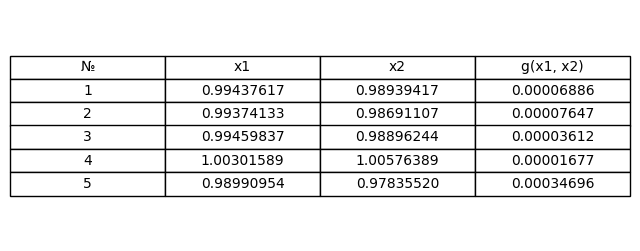

In [83]:
alpha = 0.95
initial_temp = 100
n_iterations = 10000
cooling = hyperbolic_cooling(initial_temp, alpha)

plot_sa_res(g, initial_temp, cooling, n_iterations)

run 1: x = 0.98846066, y = 0.97945135, g(x, y) = 0.00070766
run 2: x = 1.00176363, y = 1.00373128, g(x, y) = 0.00000715
run 3: x = 1.01925354, y = 1.03720622, g(x, y) = 0.00065011
run 4: x = 1.00336400, y = 1.00568822, g(x, y) = 0.00012180
run 5: x = 0.99281890, y = 0.98371679, g(x, y) = 0.00044067


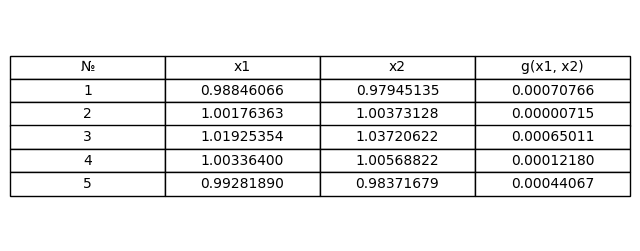

In [84]:
alpha = 0.50
initial_temp = 200
n_iterations = 10000
cooling = hyperbolic_cooling(initial_temp, alpha)

plot_sa_res(g, initial_temp, cooling, n_iterations)

x = -0.01355250, y = -0.00151422, g(x, y) = 1.02757695


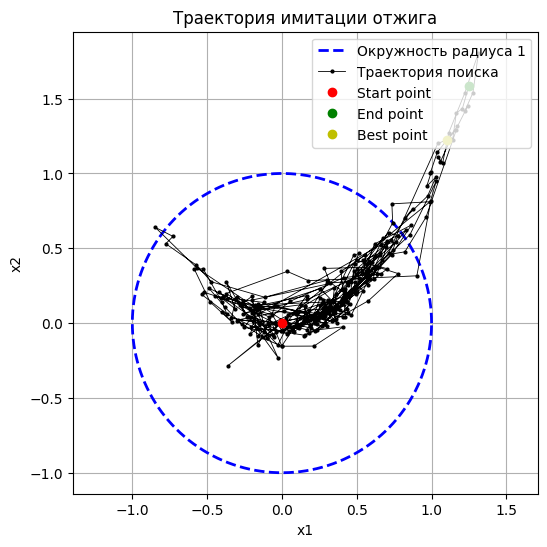

In [85]:
alpha = 0.05
initial_temp = 25
n_iterations = 1000
cooling_schedule = hyperbolic_cooling(initial_temp, alpha)

x_curr, y_curr = 0.0, 0.0
xs, ys = [x_curr], [y_curr]
best_x, best_y = x_curr, y_curr
best_val = g(x_curr, y_curr)
temp = initial_temp
sigma = 0.2
for k in range(n_iterations):
    # Генерация кандидата: приращение из N(0, sigma^2 * T)
    step_x = get_normal(0, sigma * np.sqrt(temp), 1)[0]
    step_y = get_normal(0, sigma * np.sqrt(temp), 1)[0]

    x_cand = x_curr + step_x
    y_cand = y_curr + step_y

        # Вычисление значения функции
    val_cand = g(x_cand, y_cand)
    val_curr = g(x_curr, y_curr)
    delta = val_cand - val_curr

        # Правило Метрополиса
    if delta < 0 or np.random.rand() < np.exp(-delta / temp):
        x_curr,y_curr = x_cand, y_cand
        val_curr = val_cand

            # Обновление лучшего решения
        if val_curr < best_val:
            best_x,best_y = x_curr, y_curr
            best_val = val_curr
        xs.append(x_curr)
        ys.append(y_curr)
        # Охлаждение
    temp = cooling_schedule(temp, k)
#грфик единичной окружности для наглядности
angles = np.linspace(0, 2 * np.pi, 500)
r_c = 1
# 2. Вычисляем координаты x и y по формулам: x = cos(t), y = sin(t)
x_c = r_c * np.cos(angles)
y_c = r_c * np.sin(angles)

print(f"x = {x:.8f}, y = {y:.8f}, g(x, y) = {g(x, y ):.8f}")
plt.figure(figsize=(6, 6))
plt.xlabel("x1")
plt.ylabel("x2")
plt.plot(x_c, y_c,"--", color='blue', linewidth=2, label='Окружность радиуса 1')
plt.plot(xs, ys, "ko-", markersize=2, linewidth=0.6,label="Траектория поиска")
x_start, y_start = xs[0], ys[0]
plt.plot(x_start, y_start, "ro", markersize=6, label="Start point")
x_end, y_end = xs[-1], ys[-1]
plt.plot(x_end, y_end, "go", markersize=6, label="End point")
plt.plot(best_x, best_y, "yo", markersize=6, label="Best point")
plt.grid(True)
plt.axis("equal")
plt.title("Траектория имитации отжига")
plt.legend(loc='upper right')
plt.show()

Подводя итоги, метод имитации обжига работает намного лучше случайного поиска, однако даже он справляется с задачей не идеально. Возможно, при выборе других семейств функций алгоритм будет работать лучше.

## Сравнение со стандартными методами оптимизации

Сравним работу случайных алгоритмов с классическим методом градиентного спуска. Градиент функции равен
$$ \nabla g(x_1, x_2) = \begin{bmatrix}
2 (x_1 - 1) - 400 (x_2 - x_1^2) x_1 \\
200 (x_2 - x_1^2)
\end{bmatrix} $$

In [86]:
def gradient_descent(grad, x, speed, n_iter):
    for i in range(n_iter):
        x -= speed * grad(x)
    return x

def g_grad(z):
    x, y = z
    return np.array(2 * (x - 1) - 400 * (y - x ** 2) * x, 200 * (y - x ** 2))

In [87]:
x = np.random.rand()
y = np.random.rand()
x, y = gradient_descent(g_grad, np.array([x, y]), 0.001, 1000)
print(f"x = {x}, y = {y}, g(x, y) = {g(x, y)}")

x = 1.1433227885984911, y = 1.3078137807527472, g(x, y) = 0.020580707277152152


In [88]:
n_runs = 1000

x = np.random.rand()
y = np.random.rand()
f_mean = f_best = g(x, y)
f_vals = []
for i in range(n_runs):
    x = np.random.rand()
    y = np.random.rand()
    x, y = gradient_descent(g_grad, np.array([x, y]), 0.001, 1000)
    f_mean += g(x, y)
    f_vals.append(g(x, y))
    if (g(x, y) < f_best):
        f_best = g(x, y)
f_mean /= n_runs # Выборочное среднее
f_var = np.sum(np.power(np.array(f_vals) - f_mean, 2)) / (n_runs - 1) # Выборочная дисперсия
print(f"Average function value: {f_mean}, variance: {f_var}")
print(f"total best function value: {f_best}")

Average function value: 7.713584097320633, variance: 250.53245189574946
total best function value: 7.404763916864207e-07


Градиентные методы демонстрируют более высокую скорость и точность на гладких функциях, однако стохастические методы обладают большей универсальностью и меньшей чувствительностью к начальному приближению.


# Задание 8. Решение задачи Дирихле для уравнения Лапласа методом Монте-Карло

Рассматривается первая краевая задача для двумерного уравнения Лапласа в единичном круге:
$$
\begin{cases}
\Delta u = 0, \quad (x,y)\in D,\\
u|_{\partial D} = f(x,y),\\
u \in C^2(D), \quad f \in C(\partial D),\\
D = \{(x,y)\in\mathbb{R}^2 : x^2+y^2\le 1\}.
\end{cases}
$$

Требуется:
1. приближённо найти решение методом Монте-Карло;
2. для граничной функции $f(x,y)=x^2-y^2$ выписать точное решение;
3. сопоставить численный результат с аналитическим.

## Идея вероятностного подхода

Для гармонической функции значение в  mвнутренней точке области связано со случайным блужданием: если многократно запускать траекторию из выбранного узла и останавливать её в момент первого попадания на границу, то среднее значение граничной функции в точках выхода будет приближать искомое решение.

В дискретной постановке это означает следующее:
- внутри круга строится сетка;
- из каждого внутреннего узла запускается серия случайных блужданий;
- на каждом шаге траектория переходит в один из соседних узлов с одинаковой вероятностью;
- после достижения границы фиксируется значение $f$;
- итоговое значение $u$ в стартовом узле берётся как среднее по всем траекториям.

## Сеточная аппроксимация области

Область расчёта задаётся на равномерной прямоугольной сетке в квадрате $[-1,1]\times[-1,1]$. После этого из всех узлов оставляются только те, для которых выполняется условие
$$
x^2+y^2\le 1.
$$

Среди них выделяются:
- внутренние узлы, из которых можно сделать шаг во все четыре стороны, не покидая область;
- граничные узлы, для которых хотя бы один сосед выходит за пределы круга.

На граничных узлах решение задаётся сразу:
$$
u(x,y)=f(x,y).
$$

## Схема случайного блуждания

Используется простейшее блуждание на декартовой сетке. Из текущего узла частица переходит в один из четырёх соседних узлов:
- вверх,
- вниз,
- влево,
- вправо,

причём вероятность каждого перехода равна $\frac14$.

Одно моделирование устроено так:
1. выбирается стартовый внутренний узел;
2. случайно определяется направление очередного шага;
3. траектория переносится в соседний узел;
4. если достигнута граница, процесс останавливается;
5. если граница ещё не достигнута, шаги продолжаются;
6. в момент остановки записывается значение граничной функции в точке выхода.

## Формула Монте-Карло

Пусть из точки $(x,y)$ выполнено $N$ независимых блужданий, а $(x_k^{*},y_k^{*})$ — точка первого выхода $k$-й траектории на границу. Тогда приближение решения задаётся формулой
$$
u_N(x,y)=\frac{1}{N}\sum_{k=1}^{N} f(x_k^{*},y_k^{*}).
$$

При увеличении числа траекторий значение $u_N(x,y)$ стабилизируется, а статистическая погрешность убывает как величина порядка $N^{-1/2}$.





In [89]:
def f(x, y):
    return x**2 - y**2

def in_circle(x, y):
    return x**2 + y**2 <= 1

#проверка узла на граничность
def is_boundary(x, y, step):
    if not in_circle(x, y):
        return False
    #в противном случае точка либо в окружности, либо на границе
    neighbors = [
        (x + step, y),
        (x - step, y),
        (x, y + step),
        (x, y - step)
    ]
    for nx, ny in neighbors:
        if not in_circle(nx, ny):
            return True
    return False #точка внутри окружности, но не на границе

In [90]:
def random_walk_to_boundary(start_x, start_y, step):
    x, y = start_x, start_y

    if step <= 0:
        raise ValueError("step must be > 0")
    if x*x + y*y >= 1.0:
        raise ValueError("start point must be strictly inside the unit disk")

    while not is_boundary(x, y, step):
        direction = np.random.choice(['up', 'down', 'left', 'right'])
        if direction == 'up':
            y += step
        elif direction == 'down':
            y -= step
        elif direction == 'left':
            x -= step
        elif direction == 'right':
            x += step
    return x, y

# N_iter - количество пробегов для каждой внутренней точки
# N - количество узлов по каждой оси
def monte_carlo_solution(N, N_iter):
    step = 2 / (N - 1)
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    Z = np.zeros((N, N))
#X, Y = np.meshgrid(x, y)
#mask = X**2 + Y**2 <= 1
    for i in range(N):
        for j in range(N):
            if not in_circle(x[i], y[j]):
                continue
            if is_boundary(x[i], y[j], step):
                Z[i, j] = f(x[i], y[j])
            else:
                temp_value = 0
                for _ in range(N_iter): #кол-во пробегов
                    x_end, y_end = random_walk_to_boundary(x[i], y[j], step)
                    temp_value += f(x_end, y_end)
                Z[i,j] = temp_value / N_iter
    return x, y, Z

In [91]:
def plot_solution(x, y, Z):
    X, Y = np.meshgrid(x, y)

    # Так как в твоём коде Z[i, j] соответствует точке (x[i], y[j]),
    # для стандартного meshgrid удобнее взять транспонированную матрицу
    Z_plot = Z.T

    # Дополнительно маскируем всё, что вне круга
    mask = X**2 + Y**2 <= 1
    Z_plot = np.where(mask, Z_plot, np.nan)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z_plot, cmap='viridis', edgecolor='k', linewidth=0.2)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(x, y)')
    ax.set_title('Решение задачи Лапласа методом Монте-Карло')

    plt.show()

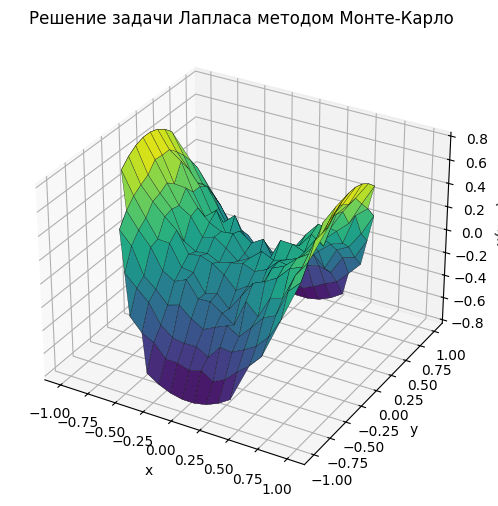

In [92]:
x_0, y_0, Z_0 = monte_carlo_solution(20, 100)
plot_solution(x_0, y_0, Z_0)

## Аналитическое решение для $f(x,y)=x^2-y^2$

Рассмотрим функцию
$$
u_{\text{exact}}(x,y)=x^2-y^2.
$$

Проверим, что она гармоническая в круге:
$$
\Delta u_{\text{exact}}=\frac{\partial^2}{\partial x^2}(x^2-y^2)+\frac{\partial^2}{\partial y^2}(x^2-y^2)=2-2=0.
$$

На границе области функция принимает значения
$$
u_{\text{exact}}|_{\partial D}=x^2-y^2=f(x,y),
$$
то есть точно удовлетворяет заданному граничному условию. Следовательно, искомое аналитическое решение задачи имеет вид
$$
u(x,y)=x^2-y^2.
$$

## Сравнение численного и точного решений




In [ ]:
def plot_exact_solution(N=20):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    Z = X**2 - Y**2

    mask = X**2 + Y**2 <= 1
    Z = np.where(mask, Z, np.nan)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', linewidth=0.2)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(x, y)')
    ax.set_title('Точное решение $u(x,y)=x^2-y^2$')

    plt.show()

In [ ]:
plot_exact_solution()

Посмотрим на погрешность метода:

In [ ]:
def compute_error(x, y, Z_mc):
    X, Y = np.meshgrid(x, y)

    # точное решение
    Z_exact = X**2 - Y**2

    # приведение к твоей системе индексов
    Z_exact = Z_exact.T

    # маска круга
    mask = X**2 + Y**2 <= 1

    # тоже транспонируем маску
    mask = mask.T

    # считаем ошибку
    error = np.abs(Z_mc - Z_exact)

    # вне круга убираем
    error = np.where(mask, error, np.nan)

    return error

def plot_error_surface(x, y, error):
    X, Y = np.meshgrid(x, y)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # важно: error уже в твоем формате → нужен transpose
    ax.plot_surface(X, Y, error.T, cmap='inferno', edgecolor='k', linewidth=0.2)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('error')
    ax.set_title('Абсолютная ошибка |u_MC - u_exact|')

    plt.show()

In [ ]:
error_0 = compute_error(x_0, y_0, Z_0)
plot_error_surface(x_0, y_0, error_0)
print(f"Максимальная абсолютная ошибка: {np.nanmax(error_0)}")

# Задание 9

Винеровским процесом $W(t),\, t \geqslant 0$, называется случайный процесс, для которого верно:
1. $W(0) = 0 \text{ п.н.}$
2. $W(t)$ &mdash; $\text{ процесс с независимыми приращениями, то есть } \forall t_0, t_1, \dots, t_n \geqslant 0 \text{ таких, что } 0 = t_0 < t_1 < \dots < t_n, \text{ случайные величины } X_{t_0}, X_{t_1} - X_{t_0},\dots, X_{t_n} - X_{t_{n-1}} \text{ независимы}.$
3. $W(t) - W(s) \sim N(0, \sigma^2(t-s)), \forall 0 \leqslant s < t,$ где $N(0, \sigma^2(t-s))$ &mdash; нормальное распределение со средним 0 и дисперсией $\sigma^2(t-s)$.

Винеровский процесс является марковским и гауссовским.

Найдем ковариационную функцию: Пусть $s \leqslant t$, тогда
$$\text{cov}(W(s), W(t)) = \mathbb{E}(W(s) - \mathbb{E}W(s))(W(t) - \mathbb{E}W(t)) = \mathbb{E}W(s)W(t) = \mathbb{E}W(s)((W(t) - W(s)) + W(s)) = \mathbb{E}W(s)(W(t) - W(s)) + \mathbb{E} W^2(s).$$
В силу независимости приращений получаем, что случайные величины
$$W(s) = W(s) - W(0) \text{ и } W(t) - W(s)$$
независимы, поэтому
$$\mathbb{E}W(s)(W(t) - W(s)) = \mathbb{E}W(s) \cdot \mathbb{E}(W(t) - W(s)) = 0.$$
Таким образом,
$$\text{cov}(W(s), W(t)) = \mathbb{E}(W^2(s)) = \text{Var}(W^2(s)) = s\sigma^2.$$
В общем случае получаем
$$\text{cov}(W(s), W(t)) = \text{min}(s, t)\sigma^2.$$

Теперь рассмотрим переходные вероятности. Пусть, как и раньше, $0 \leqslant s < t$. Нас интересует условная плотность распределения:
$$p_{W(t)|W(s)}(y|x) = \frac{p_{W(s),W(t)}(x,y)}{p_{W(s)}(x)}$$
Заметим, что
$$W(t) = W(t) - W(0) \sim N(0, \sigma^2t),\, W(s) = W(s) - W(0) \sim N(0, \sigma^2s),$$
поэтому случайный вектор $(W(s), W(t))$ имеет двумерное нормальное распределение с матожиданием $\mu = (0, 0)$ и ковариационной матрицей
$$\Sigma = \begin{bmatrix}
\text{cov}(W(s), W(s)) & \text{cov}(W(s), W(t))\\
\text{cov}(W(t), W(s)) & \text{cov}(W(t), W(t))\\
\end{bmatrix} = \sigma^2\begin{bmatrix}
s & s\\
s & t\\
\end{bmatrix},$$
$$\text{det}(\Sigma) = \sigma^4s(t-s),$$
$$\Sigma^{-1} = \frac{1}{\sigma^2s(t-s)}\begin{bmatrix}
t & -s\\
-s & s\\
\end{bmatrix}.$$
Таким образом,
$$
p_{W(s), W(t)}(x, y) = \frac{1}{2\pi \sigma^2 \sqrt{s(t-s)}}e^{-\frac{1}{2\sigma^2s(t-s)}\begin{bmatrix}x & y\end{bmatrix}\begin{bmatrix}
t & -s\\
-s & s\\
\end{bmatrix}\begin{bmatrix}x \\ y\end{bmatrix}} =
\frac{1}{2\pi \sigma^2 \sqrt{s(t-s)}}e^{-\frac{1}{2\sigma^2s(t-s)}(tx^2 - 2sxy + sy^2)},
$$
$$p_{W(s)}(x) = \frac{1}{\sqrt{2\pi s}\sigma}e^{-\frac{1}{2}\frac{x^2}{\sigma^2s}},$$
и
$$
p_{W(t)|W(s)}(y|x) = \frac{\sqrt{2\pi s}\sigma}{2\pi \sigma^2 \sqrt{s(t-s)}}e^{-\frac{1}{2\sigma^2s(t-s)}(tx^2 - 2sxy + sy^2) + \frac{1}{2}\frac{x^2}{\sigma^2s}} =
\frac{1}{\sqrt{2\pi(t-s)} \sigma}e^{-\frac{1}{2\sigma^2s(t-s)}(sx^2 - 2sxy + sy^2)} =
\frac{1}{\sqrt{2\pi(t-s)} \sigma}e^{-\frac{1}{2\sigma^2(t-s)}(y - x)^2}.
$$
Значит,
$$(W(t)|W(s)=x) \sim N(x, \sigma^2(t - s))$$

Для метода разбиения отрезка нам также понадобится условная вероятность для средней точки отрезка при известных крайних. Пусть $0 \leqslant t_1 < t_2 < t_3$. Тогда
$$p_{W(t_2)|W(t_1),W(t_3)}(y|x,z) = \frac{p_{W(t_1),W(t_2),W(t_3)}(x,y,z)}{p_{W(t_1),W(t_3)}(x,z)},$$
$$\Sigma_{t_1, t_2, t_3} = \sigma^2\begin{bmatrix}
t_1 & t_1 & t_1\\
t_1 & t_2 & t_2\\
t_1 & t_2 & t_3\\
\end{bmatrix},$$
$$\text{det}(\Sigma_{t_1, t_2, t_3}) = \sigma^6t_1(t_2 - t_1)(t_3 - t_2),$$
$$\Sigma_{t_1, t_2, t_3}^{-1} = \frac{1}{\sigma^2t_1(t_2 - t_1)(t_3 - t_2)}\begin{bmatrix}
t_2(t_3 - t_2) & t_1(t_2 - t_3) & 0\\
t_1(t_2 - t_3) & t_1(t_3 - t_1) & t_1(t_1 - t_2)\\
0 & t_1(t_1 - t_2) & t_1(t_2 - t_1)\\
\end{bmatrix},$$
$$p_{W(t_1),W(t_2),W(t_3)}(x,y,z) = \frac{1}{\left(2\pi\sigma^2\right)^{\frac{3}{2}}\sqrt{t_1(t_2 - t_1)(t_3 - t_2)}}e^{-\frac{1}{2\sigma^2t_1(t_2 - t_1)(t_3 - t_2)}\begin{bmatrix}x & y & z\end{bmatrix}\begin{bmatrix}
t_2(t_3 - t_2) & t_1(t_2 - t_3) & 0\\
t_1(t_2 - t_3) & t_1(t_3 - t_1) & t_1(t_1 - t_2)\\
0 & t_1(t_1 - t_2) & t_1(t_2 - t_1)\\
\end{bmatrix}\begin{bmatrix}x \\ y \\ z\end{bmatrix}}.$$

В методе разбиения отрезка мы будем брать $t_2 = \frac{t_1 + t_3}{2}$, поэтому
$$\text{det}(\Sigma_{t_1, t_2, t_3}) = \sigma^6t_1(\frac{t_1 + t_3}{2} - t_1)(t_3 - \frac{t_1 + t_3}{2}) = \sigma^6t_1\left(\frac{t_3 - t_1}{2}\right)^2,$$
$$\Sigma_{t_1, t_2, t_3}^{-1} = \frac{1}{\sigma^2t_1\left(\frac{t_3 - t_1}{2}\right)^2}\begin{bmatrix}
\frac{t_1 + t_3}{2}\frac{t_3 - t_1}{2} & t_1\frac{t_1 - t_3}{2} & 0\\
t_1\frac{t_1 - t_3}{2} & t_1(t_3 - t_1) & t_1\frac{t_1 - t_3}{2}\\
0 & t_1\frac{t_1 - t_3}{2} & t_1\frac{t_3 - t_1}{2}\\
\end{bmatrix},$$
$$p_{W(t_1),W(t_2),W(t_3)}(x,y,z) = \frac{1}{\left(2\pi\sigma^2\right)^{\frac{3}{2}}\sqrt{t_1}\frac{t_3 - t_1}{2}}e^{-\frac{2}{\sigma^2t_1(t_3 - t_1)^2}\begin{bmatrix}x & y & z\end{bmatrix}\begin{bmatrix}
\frac{t_3^2 - t_1^2}{4} & t_1\frac{t_1 - t_3}{2} & 0\\
t_1\frac{t_1 - t_3}{2} & t_1(t_3 - t_1) & t_1\frac{t_1 - t_3}{2}\\
0 & t_1\frac{t_1 - t_3}{2} & t_1\frac{t_3 - t_1}{2}\\
\end{bmatrix}\begin{bmatrix}x \\ y \\ z\end{bmatrix}} =
\frac{1}{\pi^{\frac{3}{2}}\sigma^3\sqrt{2 t_1}(t_3 - t_1)}e^{-\frac{2}{\sigma^2t_1(t_3 - t_1)^2}\left(\frac{t_3^2 - t_1^2}{4}x^2 + y(x + z - y)t_1(t_1 - t_3) + t_1\frac{t_3 - t_1}{2}z^2\right)},
$$
$$
p_{W(t_1), W(t_3)}(x, z) = \frac{1}{2\pi \sigma^2 \sqrt{t_1(t_3-t_1)}}e^{-\frac{1}{2\sigma^2t_1(t_3-t_1)}(t_3x^2 - 2t_1xz + t_1z^2)},
$$
$$p_{W(t_2)|W(t_1),W(t_3)}(y|x,z) = \frac{2\pi \sigma^2 \sqrt{t_1(t_3-t_1)}}{\pi^{\frac{3}{2}}\sigma^3\sqrt{2 t_1}(t_3 - t_1)}e^{-\frac{2}{\sigma^2t_1(t_3 - t_1)^2}\left(\frac{t_3^2 - t_1^2}{4}x^2 + y(x + z - y)t_1(t_1 - t_3) + t_1\frac{t_3 - t_1}{2}z^2\right) + \frac{1}{2\sigma^2t_1(t_3-t_1)}(t_3x^2 - 2t_1xz + t_1z^2)}.$$
$$ -\frac{2}{\sigma^2t_1(t_3 - t_1)^2}\left(\frac{t_3^2 - t_1^2}{4}x^2 + y(x + z - y)t_1(t_1 - t_3) + t_1\frac{t_3 - t_1}{2}z^2\right) + \frac{1}{2\sigma^2t_1(t_3-t_1)}(t_3x^2 - 2t_1xz + t_1z^2) = $$
$$ = \frac{1}{2\sigma^2t_1(t_3 - t_1)^2}\left(-(t_3 - t_1)(t_3 + t_1)x^2 + 4t_1(t_3 - t_1)y(x + z - y) - 2t_1(t_3 - t_1)z^2 + t_3(t_3 - t_1)x^2 - 2t_1(t_3 - t_1)xz + t_1(t_3 - t_1)z^2\right) = $$
$$ = \frac{1}{2\sigma^2t_1(t_3 - t_1)^2}\left(-4t_1(t_3 - t_1)y^2 + 4t_1(t_3 - t_1)(x + z)y + (-(t_3 - t_1)(t_3 + t_1)x^2 - 2t_1(t_3 - t_1)z^2 + t_3(t_3 - t_1)x^2 - 2t_1(t_3 - t_1)xz + t_1(t_3 - t_1)z^2)\right) = $$
$$ = -\frac{1}{2\sigma^2(t_3 - t_1)}\left(4y^2 - 4y(x + z) + (x^2 + 2xz + z^2)\right) = -\frac{2}{\sigma^2(t_3 - t_1)}\left(y - \frac{x + z}{2}\right)^2 \Rightarrow$$
$$ \Rightarrow p_{W(t_2)|W(t_1),W(t_3)}(y|x,z) = \frac{1}{\sigma\sqrt{\pi \frac{t_3-t_1}{2}}}e^{-\frac{2}{\sigma^2(t_3 - t_1)}\left(y - \frac{x + z}{2}\right)^2} = \frac{1}{\sigma\sqrt{2\pi \frac{t_3-t_1}{4}}}e^{-\frac{1}{2\sigma^2\frac{t_3 - t_1}{4}}\left(y - \frac{x + z}{2}\right)^2}.$$
Таким образом, получаем, что
$$(W(t_2)|W(t_1)=x,W(t_3)=z) \sim N(\frac{x + z}{2}, \sigma^2\frac{t_3 - t_1}{4}).$$

## Процесс Орнштейна-Уленбека

Процесс Орнштейна-Уленбека $X(t), t \in [0, 1], X(0) = X_0$ &mdash; единственный нетривиальный гауссовский процесс, являющийся стационарным и обладающий марковским свойством. Начальные значения $X_0$ выбираются случайным образом так, чтобы процесс был стационарным. Для этого необходимо и достаточно, чтобы $X_0 \sim N(\mu, \sigma^2)$

Выведем ковариационную функцию процесса. Пусть $0 \leqslant s < t$. Без ограничения общности, рассмотрим процессы с $\mu = 0$. В силу стационарности процесса,
$$\text{cov}(X(s), X(t)) = \text{cov}(X(0), X(t-s)) = K(t-s).$$
Рассмотрим условное матожидание $\mathbb{E}(X(t + h)|X(t))$. В силу того, что $X(t + h)$ и $X(t)$ &mdash; совместно гауссовские случайные величины,
$$\mathbb{E}(X(t + h)|X(t)) = \frac{\text{cov}(X(t + h), X(t))}{\text{Var(X(t))}}X(t) = \frac{K(h)}{\sigma^2}X(t).$$
Теперь посчитаем величину $\mathbb{E}(X(t + h + s)|X(t))$ двумя способами. С одной стороны,
$$\mathbb{E}(X(t + h + s)|X(t)) = \frac{K(h + s)}{\sigma^2}X(t).$$
С другой же, используя марковское свойство и свойства условного матожидания,
$$\mathbb{E}(X(t + h + s)|X(t)) = \mathbb{E}(\mathbb{E}(X(t + h + s)|X(t + h))|X(t)) = \mathbb{E}(\frac{K(s)}{\sigma^2}X(t + h)|X(t)) = \frac{K(s)}{\sigma^2}\frac{K(h)}{\sigma^2}X(t).$$
Таким образом,
$$\frac{K(h + s)}{\sigma^2}X(t) = \frac{K(s)}{\sigma^2}\frac{K(h)}{\sigma^2}X(t),$$
$$\frac{K(h + s)}{\sigma^2} = \frac{K(s)}{\sigma^2}\frac{K(h)}{\sigma^2}.$$
В силу непрерывности решений, получаем, что уравнение имеет единственное решение
$$\frac{K(h)}{\sigma^2} = e^{-\theta h}$$
для некоторой константы $\theta$. В силу того, что корреляция должна быть ограничена, получаем, что $\theta > 0$. В общем случае, имеем
$$K(h) = \sigma^2 e^{\theta\vert h \vert}$$

Процесс нахождения переходных вероятностей аналогичен случаю винеровского процесса, в котором нужно заменить ковариационную функцию на соответствующую функцию для процесса Орнштейна-Уленбека, и учесть ненулевое матожидание. В итоге получим, что если $X_0 \sim N(\mu, \sigma^2)$, то
$$(X(t) | X_0 = x) \sim N(\mu + (x - \mu)e^{-\theta t}, \sigma^2(1 - e^{-2 \theta t})),$$
$$(X(t_2) | X(t_1) = x,X(t_3) = z) \sim N(\frac{x + z}{e^{\theta h} + e^{-\theta h}}, \sigma^2\frac{e^{2 \theta h} - 1}{e^{2 \theta h} + 1}),$$
где $t \geqslant 0,\, t_1 < t_3,\, t_2 = \frac{t_1 + t_3}{2},\, h = \frac{t_3 - t_1}{2}$.

## Моделирование процессов

Промоделируем процессы, используя метод разбиения отрезка. Для этого сначала сгенерируем величину в нулевой момент времени из безусловного распределения, потом в момент $t = 1$ при условии начального значения, а далее будем делить отрезки пополам и генерировать значения посередине при условии значений на концах.

In [93]:
def wiener_cov(s, t):
    return min(s, t)

def ornstein_uhlenbeck_cov(s, t, theta=1.0, sigma=1.0):
    return (sigma ** 2 / (2 * theta)) * np.exp(-theta * abs(t - s))

In [94]:
def wiener_cov(s, t):
    return min(s, t)

def ornstein_uhlenbeck_cov(s, t, theta=1.0, sigma=1.0):
    return (sigma ** 2 / (2 * theta)) * np.exp(-theta * abs(t - s))

In [95]:
def wiener_process(num_p, num_tr):
    t = np.linspace(0, 1, num_p)
    dt = t[1] - t[0]
    traj = np.zeros((num_tr, num_p))

    for i in range(num_tr):
        increments = np.random.normal(0, np.sqrt(dt), num_p - 1)
        traj[i, 1:] = np.cumsum(increments)

    return t, traj

In [96]:
def ornstein_uhlenbeck(num_p, num_tr, theta=1.0, sigma=1.0):
    t = np.linspace(0, 1, num_p)
    dt = t[1] - t[0]
    traj = np.zeros((num_tr, num_p))

    for i in range(num_tr):
        x0 = np.random.normal(0, np.sqrt(sigma ** 2 / (2 * theta)))
        traj[i, 0] = x0
        for j in range(1, num_p):
            mean = traj[i, j - 1] * np.exp(-theta * dt)
            variance = sigma ** 2 * (1 - np.exp(-2 * theta * dt)) / (2 * theta)
            traj[i, j] = mean + np.random.normal(0, np.sqrt(variance))

    return t, traj

3. Построить график траектории, не соединяя точки ломаной, с целью получения визуально непрерывной линии.

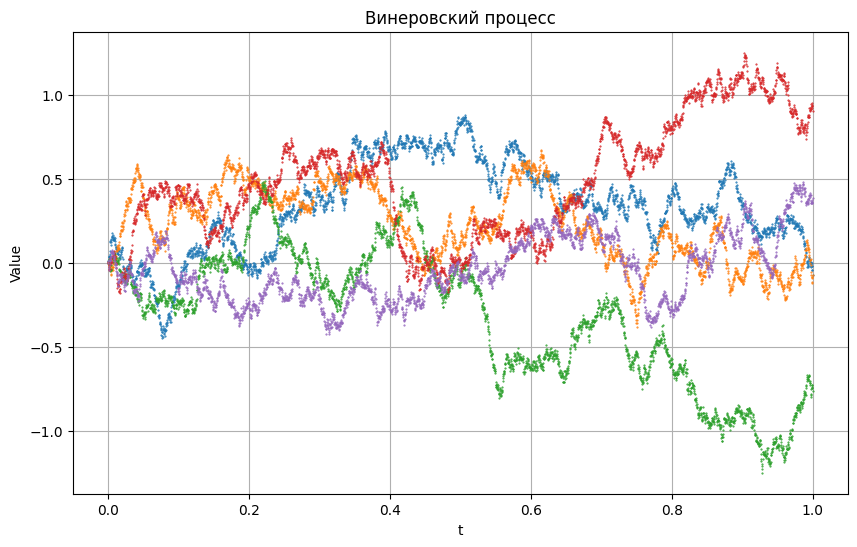

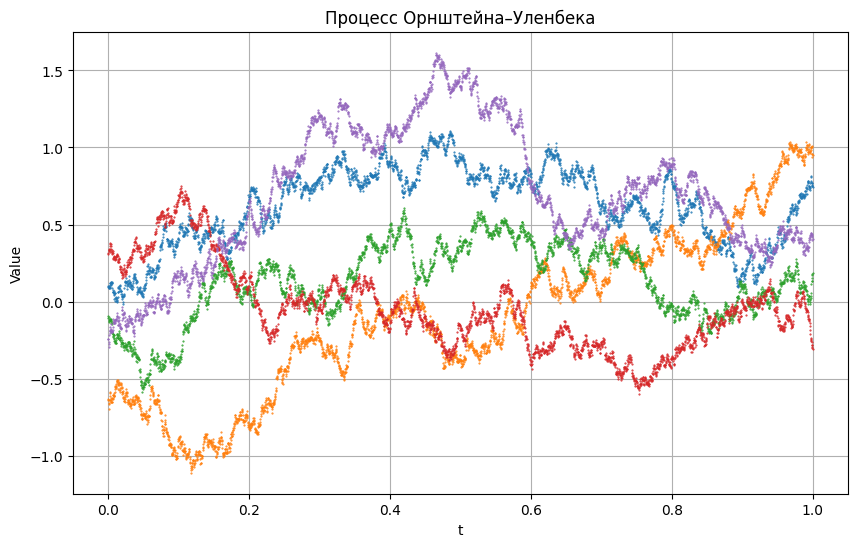

In [97]:
def plot_trajectories(t, traj, title):
    plt.figure(figsize=(10, 6))
    for trajectory in traj:
        plt.plot(t, trajectory, marker="o", linestyle="none", markersize=0.5)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

num_p = 3000
num_tr = 5

t_wiener, wiener_tr = wiener_process(num_p, num_tr)
plot_trajectories(t_wiener, wiener_tr, "Винеровский процесс")

t_ou, ou_trajectories = ornstein_uhlenbeck(num_p, num_tr)
plot_trajectories(t_ou, ou_trajectories, "Процесс Орнштейна–Уленбека")


При анализе реальных временных рядов наблюдения, как правило, содержат шум.
Для моделирования этой ситуации будем считать, что наблюдаемый процесс отличается
от истинного добавлением случайной помехи:

$$
Y(t) = X(t) + \eta(t),
$$

где  
- $X(t)$ — истинный процесс Орнштейна–Уленбека (OU-процесс),  
- $\eta(t)$ — шум наблюдений.

Задача состоит в том, чтобы по наблюдаемым данным $Y(t)$ восстановить
неизвестную траекторию истинного процесса $X(t)$.

Рассмотрим два типа шума наблюдений.

### 1. Гауссов шум

В этом случае шум имеет нормальное распределение

$$
\eta(t) \sim N(0,\sigma_\eta^2),
$$

где $\sigma_\eta^2$ — дисперсия шума.  
Такая модель является стандартной для задач фильтрации сигналов.

### 2. Шум Коши

Другой возможный вариант — шум с распределением Коши

$$
\eta(t) \sim \text{Cauchy}(x_0,\gamma),
$$

где  
- $x_0$ — параметр положения (центр распределения),  
- $\gamma$ — параметр масштаба.

Распределение Коши характеризуется тяжёлыми хвостами, поэтому в наблюдениях
могут появляться значительные выбросы, что существенно усложняет задачу
восстановления сигнала.

---

## Фильтр Калмана

Для оценки скрытого состояния системы при наличии гауссовского шума
используется фильтр Калмана. Этот алгоритм позволяет последовательно
обновлять оценку истинного процесса $X(t)$ на основе поступающих наблюдений.

Алгоритм состоит из двух основных этапов.

### 1. Шаг прогноза

На этом этапе вычисляется прогноз состояния системы на следующий момент времени.

Прогноз состояния:

$$
\hat{X}_{k|k-1} = F\,\hat{X}_{k-1|k-1},
$$

где

$$
F = e^{-\theta \Delta t}.
$$

Одновременно обновляется дисперсия ошибки прогноза:

$$
P_{k|k-1} = F^2 P_{k-1|k-1} + Q,
$$

где

$$
Q = \frac{\sigma^2}{2\theta}\left(1 - e^{-2\theta\Delta t}\right).
$$

---

### 2. Шаг коррекции (обновления)

После получения нового наблюдения производится уточнение оценки состояния.

Сначала вычисляется коэффициент Калмана:

$$
K_k = \frac{P_{k|k-1}}{P_{k|k-1} + R},
$$

где

$$
R = \sigma_\eta^2
$$

— дисперсия шума наблюдений.

Затем корректируется оценка состояния:

$$
\hat{X}_{k|k} =
\hat{X}_{k|k-1}
+ K_k\bigl(Y_k - \hat{X}_{k|k-1}\bigr).
$$

После этого обновляется дисперсия ошибки:

$$
P_{k|k} = (1-K_k)P_{k|k-1}.
$$

In [98]:
def generate_noisy_ou_process(n_points, theta=1.0, sigma=1.0, noise_std=0.5, noise_type="gaussian"):
    t = np.linspace(0, 1, n_points)
    dt = t[1] - t[0]

    x = np.zeros(n_points)
    x[0] = np.random.normal(0, np.sqrt(sigma**2 / (2 * theta)))

    for i in range(1, n_points):
        mean = x[i - 1] * np.exp(-theta * dt)
        var = sigma**2 * (1 - np.exp(-2 * theta * dt)) / (2 * theta)
        x[i] = mean + np.random.normal(0, np.sqrt(var))

    if noise_type == "gaussian":
        noise = np.random.normal(0, noise_std, n_points)
    elif noise_type == "cauchy":
        noise = np.random.standard_cauchy(n_points) * noise_std
    else:
        raise ValueError("Unknown noise type")

    observed = x + noise
    return t, x, observed


def kalman_filter(observed, dt, theta=1.0, sigma=1.0, noise_std=0.5):
    n = len(observed)

    x_est = np.zeros(n)
    P = np.zeros(n)

    x_est[0] = 0
    P[0] = sigma**2 / (2 * theta)

    for i in range(1, n):
        F = np.exp(-theta * dt)
        Q = sigma**2 * (1 - np.exp(-2 * theta * dt)) / (2 * theta)

        # прогноз
        x_pred = F * x_est[i - 1]
        P_pred = F**2 * P[i - 1] + Q

        # обновление
        R = noise_std**2
        K = P_pred / (P_pred + R)

        x_est[i] = x_pred + K * (observed[i] - x_pred)
        P[i] = (1 - K) * P_pred

    return x_est

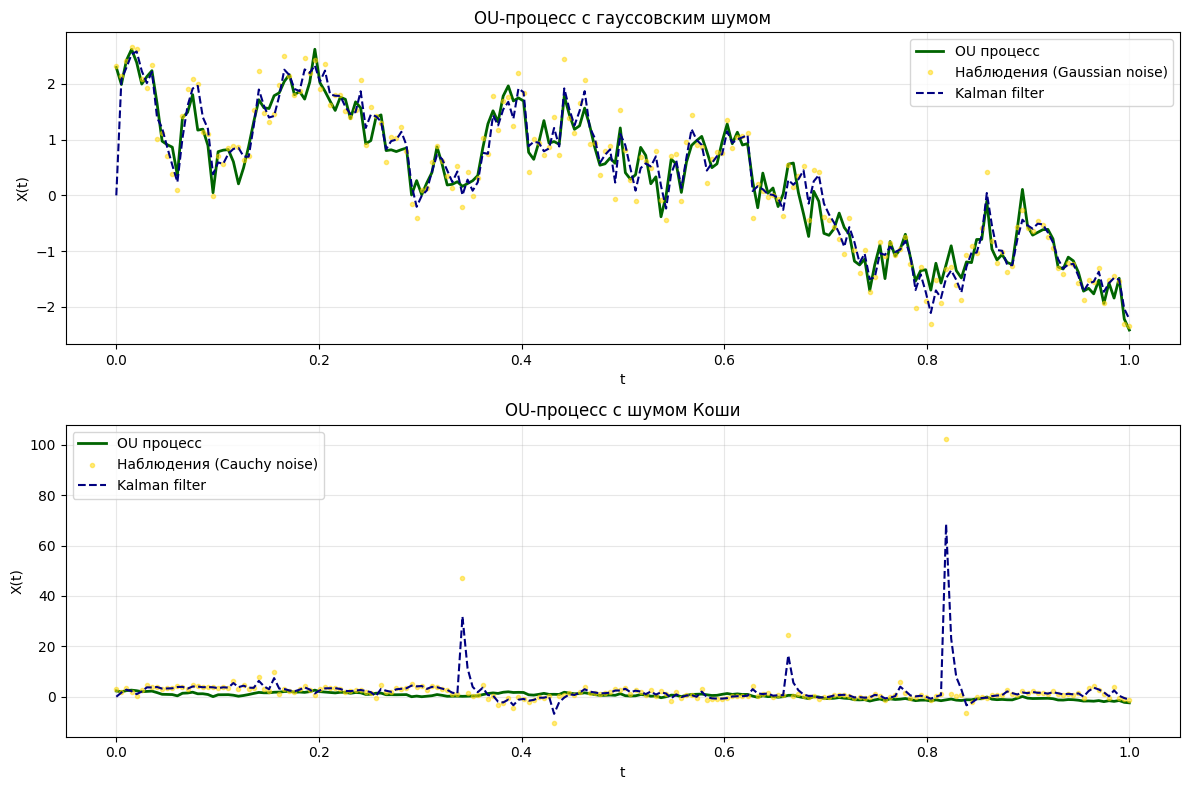

In [99]:
num_p = 200
noise_std = 0.3
theta = 4.0
sigma = 5.0

t, true_x, noisy_gauss = generate_noisy_ou_process(num_p, theta, sigma, noise_std, noise_type="gaussian")
t, _, noisy_cauchy = generate_noisy_ou_process(num_p, theta, sigma, noise_std, noise_type="cauchy")

filtered_gauss = kalman_filter(noisy_gauss, t[1] - t[0], theta, sigma, noise_std)
filtered_cauchy = kalman_filter(noisy_cauchy, t[1] - t[0], theta, sigma, noise_std)

plt.figure(figsize=(12, 8))

# Гауссовский шум
plt.subplot(2, 1, 1)
plt.plot(t, true_x, label="OU процесс", color="darkgreen", linewidth=2)
plt.plot(t, noisy_gauss, ".", label="Наблюдения (Gaussian noise)", alpha=0.5, color="gold")
plt.plot(t, filtered_gauss, "--", label="Kalman filter", color="navy")
plt.legend()
plt.title("OU-процесс с гауссовским шумом")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid(alpha=0.3)

# Шум Коши
plt.subplot(2, 1, 2)
plt.plot(t, true_x, label="OU процесс", color="darkgreen", linewidth=2)
plt.plot(t, noisy_cauchy, ".", label="Наблюдения (Cauchy noise)", alpha=0.5, color="gold")
plt.plot(t, filtered_cauchy, "--", label="Kalman filter", color="navy")
plt.legend()
plt.title("OU-процесс с шумом Коши")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
def noisy_x_cauchy(x, noise_std):
    """
    Добавляет к траектории x шум Коши.

    x : истинная траектория процесса
    noise_std : параметр масштаба шума
    """
    noise = np.random.standard_cauchy(len(x)) * noise_std
    return x + noise

ValueError: x and y must have same first dimension, but have shapes (200,) and (1,)

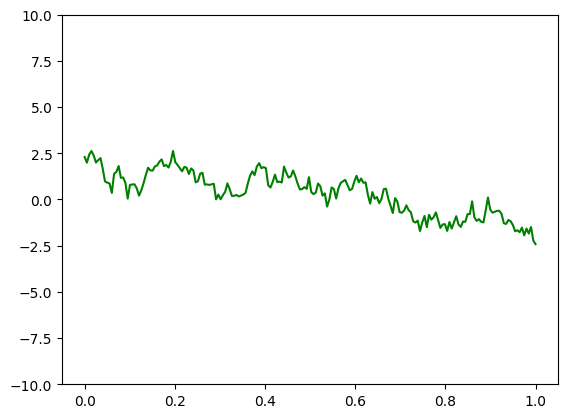

In [101]:
plt.ylim([-10, 10])
plt.plot(t, true_x, label="Процесс Орнштейна–Уленбека", alpha=1, color="green")
plt.plot(t, noisy_x_cauchy, label="Шум (Коши)", linestyle="none", marker=".", alpha=0.5, color="yellow")
plt.plot(t, filtered_x_cauchy, label="Фильтер (Калмана)", linestyle="--", alpha=0.5, color="blue")
plt.legend()
plt.title("Процесс Орнштейна–Уленбека с шумом Коши")
plt.xlabel("t")
plt.ylabel("OrnSt")
plt.grid()